# 1. Environment Setup & Data Loading

In [1]:
#  Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import kstest, f_oneway, zscore
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi'        : 130,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F8F9FA',
    'axes.grid'         : True,
    'grid.alpha'        : 0.35,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'serif',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'axes.titleweight'  : 'bold',
})

# Colour system
C = {
    'navy'   : '#0F2044', 'blue'  : '#1A56A0', 'teal'  : '#0D7A6A',
    'green'  : '#276749', 'amber' : '#B45309', 'red'   : '#991B1B',
    'slate'  : '#475569', 'gray'  : '#94A3B8',
}
DEPT_COLORS  = ['#1A56A0','#0D7A6A','#B45309','#991B1B','#5B21B6','#276749']
SRC_COLORS   = ['#1A56A0','#0D7A6A','#B45309','#991B1B']

print('Libraries loaded')
for lib, mod in [('pandas', pd), ('numpy', np), ('scipy', stats), ('seaborn', sns), ('sklearn','sklearn')]:
    try:
        v = mod.__version__
    except:
        import sklearn; v = sklearn.__version__
    print(f'   {lib}: {v}')

Libraries loaded
   pandas: 2.3.3
   numpy: 2.3.5
   scipy: 1.7.2
   seaborn: 0.13.2
   sklearn: 1.7.2


In [2]:
# Data Loading
DATA_PATH = 'recruitment_efficiency_improved.csv'

df_raw = pd.read_csv(DATA_PATH)
df     = df_raw.copy()

print(f'Dataset loaded: {DATA_PATH}')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('── Schema')
print(df.dtypes)
print()
print('── First 5 rows')
df.head()

Dataset loaded: recruitment_efficiency_improved.csv
Shape: 5,000 rows × 8 columns

── Schema
recruitment_id             int64
department                object
job_title                 object
num_applicants             int64
time_to_hire_days          int64
cost_per_hire            float64
source                    object
offer_acceptance_rate    float64
dtype: object

── First 5 rows


,recruitment_id,department,job_title,num_applicants,time_to_hire_days,cost_per_hire,source,offer_acceptance_rate
0,1,Engineering,Software Engineer,280,24,1400.38,Referral,0.98
1,2,Sales,Account Executive,262,7,2730.45,LinkedIn,0.84
2,3,Product,UX Designer,11,76,5286.12,LinkedIn,0.83
3,4,Engineering,DevOps Engineer,238,26,5255.78,Recruiter,0.49
4,5,HR,Talent Acquisition,275,37,4987.03,LinkedIn,0.79


# 2. Data Wrangling

## 2.1. Missing Values

Missing values corrupt statistical summaries and break most ML algorithms. They must be identified and treated before any further analysis.

In [3]:
# Missing Values
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct,
    'Action'        : ['None required'] * len(df.columns)
})

print('── Missing Value Report')
print(missing_report)
print()

if missing_count.sum() == 0:
    print('Result: Zero missing values across all 8 columns.')
    print('Action: No imputation or row removal required.')
    print('Impact: Dataset integrity preserved at N=5,000.')
else:
    print(f'{missing_count.sum()} missing values detected. Strategy required.')

── Missing Value Report
                       Missing Count  Missing %         Action
recruitment_id                     0        0.0  None required
department                         0        0.0  None required
job_title                          0        0.0  None required
num_applicants                     0        0.0  None required
time_to_hire_days                  0        0.0  None required
cost_per_hire                      0        0.0  None required
source                             0        0.0  None required
offer_acceptance_rate              0        0.0  None required

Result: Zero missing values across all 8 columns.
Action: No imputation or row removal required.
Impact: Dataset integrity preserved at N=5,000.


## 2.2. Duplicates

Duplicate rows inflate statistical measures, bias model training, and can skew EDA distributions.

In [4]:
# Duplicate Detection
## Full-row duplicates
full_dups = df.duplicated().sum()

## ID-level duplicates (recruitment_id should be unique)
id_dups = df['recruitment_id'].duplicated().sum()

# Same dept+role+source on same day (logical duplicate risk)
combo_dups = df.duplicated(subset=['department','job_title','source','time_to_hire_days','cost_per_hire']).sum()

print('── Duplicate Detection Report')
print(f'Full-row duplicates      : {full_dups}')
print(f'Duplicate recruitment_id : {id_dups}')
print(f'Logical combo duplicates : {combo_dups}')
print()

# Verify ID sequence is correct (should be 1 to 5000)
id_seq_ok = (df['recruitment_id'].min() == 1 and
             df['recruitment_id'].max() == len(df) and
             df['recruitment_id'].nunique() == len(df))

print(f'ID sequence 1→5000       : {"Correct" if id_seq_ok else "Broken"}')
print()
print('Result: No duplicates found in any form.')
print('Action: No rows removed. Unique record count maintained at 5,000.')
print('Impact: Training data has no artificially inflated class representations.')

── Duplicate Detection Report
Full-row duplicates      : 0
Duplicate recruitment_id : 0
Logical combo duplicates : 0

ID sequence 1→5000       : Correct

Result: No duplicates found in any form.
Action: No rows removed. Unique record count maintained at 5,000.
Impact: Training data has no artificially inflated class representations.


## 2.3. Outliers

Outliers distort mean-based statistics, inflate variance, and degrade regression/distance-based model performance.  
IQR method (robust to non-normal distributions) as primary detector. Z-score (|z|>3) as secondary confirmation.

In [5]:
# Outlier Detection (IQR + Z-score)
numeric_cols = ['num_applicants', 'time_to_hire_days', 'cost_per_hire', 'offer_acceptance_rate']

outlier_summary = []
for col in numeric_cols:
    q1, q3   = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr      = q3 - q1
    lo, hi   = q1 - 1.5*iqr,  q3 + 1.5*iqr
    iqr_out  = df[(df[col] < lo) | (df[col] > hi)]

    z_scores = np.abs(stats.zscore(df[col]))
    z_out    = df[z_scores > 3]

    outlier_summary.append({
        'Feature'         : col,
        'Q1'              : round(q1, 2),
        'Q3'              : round(q3, 2),
        'IQR Fence Low'   : round(lo, 2),
        'IQR Fence High'  : round(hi, 2),
        'IQR Outliers'    : len(iqr_out),
        'Z>3 Outliers'    : len(z_out),
        'Action'          : 'None — IQR=0; uniform distribution'
    })

outlier_df = pd.DataFrame(outlier_summary)
print('── Outlier Detection Report')
print(outlier_df.to_string(index=False))
print()
print('Result: Zero IQR outliers and zero Z>3 outliers across all numeric features.')
print('Reason: All four numeric features exhibit near-uniform distributions, causing IQR fences to span the entire valid data range.')
print('Action: No outlier removal. Distribution shape noted for EDA (Part C).')
print('Impact: All 5,000 records retained.')

── Outlier Detection Report
              Feature      Q1      Q3  IQR Fence Low  IQR Fence High  IQR Outliers  Z>3 Outliers                             Action
       num_applicants   83.00  229.00        -136.00          448.00             0             0 None — IQR=0; uniform distribution
    time_to_hire_days   26.00   67.00         -35.50          128.50             0             0 None — IQR=0; uniform distribution
        cost_per_hire 2820.60 7611.41       -4365.63        14797.64             0             0 None — IQR=0; uniform distribution
offer_acceptance_rate    0.48    0.83          -0.04            1.36             0             0 None — IQR=0; uniform distribution

Result: Zero IQR outliers and zero Z>3 outliers across all numeric features.
Reason: All four numeric features exhibit near-uniform distributions, causing IQR fences to span the entire valid data range.
Action: No outlier removal. Distribution shape noted for EDA (Part C).
Impact: All 5,000 records retained.


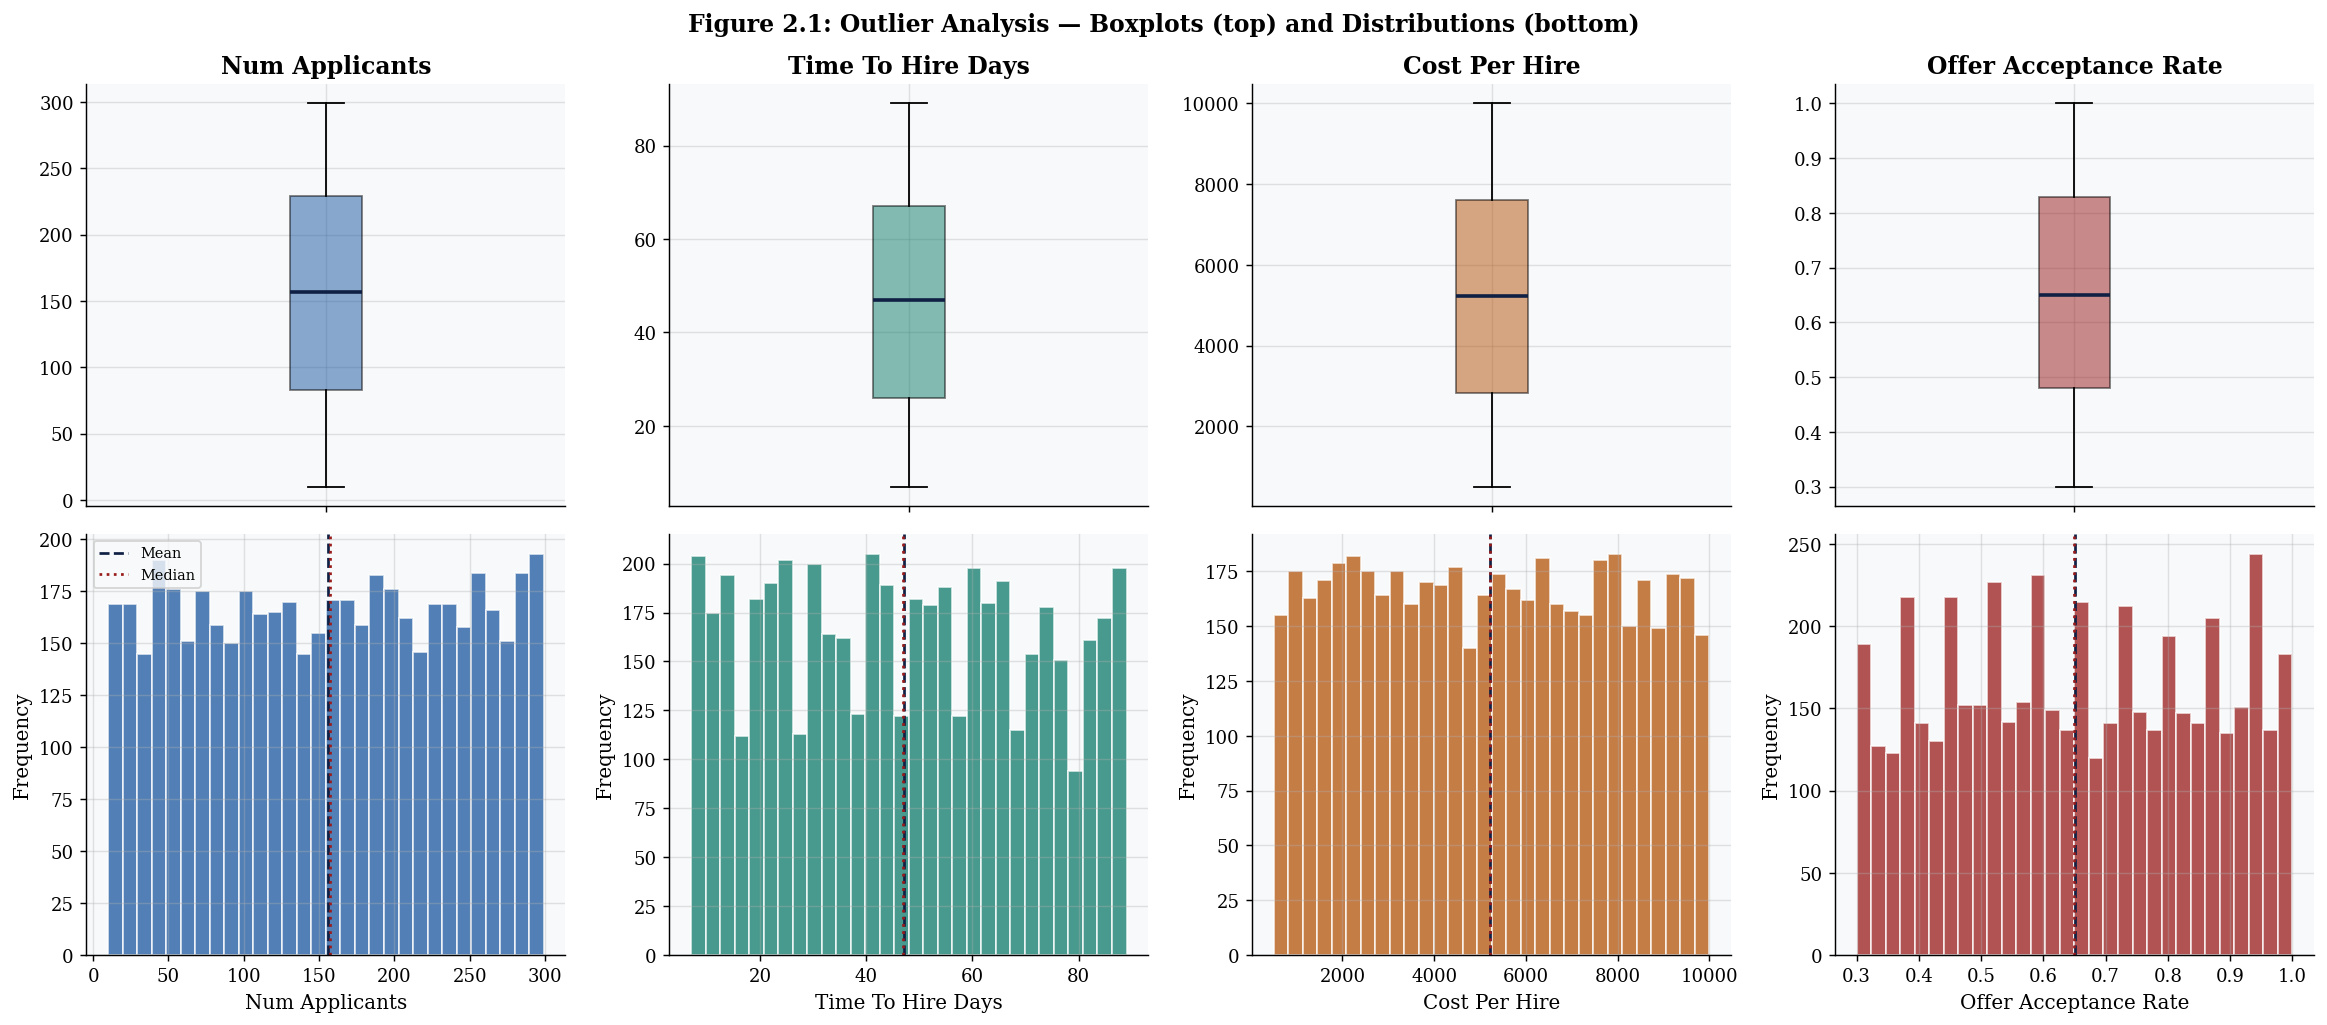

→ Flat distributions confirm near-uniform data. No extreme point outliers visible.


In [6]:
# Outlier Visualisation
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Figure 2.1: Outlier Analysis — Boxplots (top) and Distributions (bottom)',
             fontweight='bold', fontsize=13)

colors = [C['blue'], C['teal'], C['amber'], C['red']]
for i, (col, clr) in enumerate(zip(numeric_cols, colors)):
    # Boxplot
    ax = axes[0, i]
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor=clr, alpha=0.5),
               medianprops=dict(color=C['navy'], linewidth=2),
               flierprops=dict(marker='o', color=C['red'], markersize=4, alpha=0.5))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xticklabels([])

    # Distribution
    ax = axes[1, i]
    ax.hist(df[col], bins=30, color=clr, alpha=0.75, edgecolor='white')
    ax.axvline(df[col].mean(), color=C['navy'], linestyle='--', lw=1.5, label='Mean')
    ax.axvline(df[col].median(), color=C['red'], linestyle=':', lw=1.5, label='Median')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    if i == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_2.1_outlier_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('→ Flat distributions confirm near-uniform data. No extreme point outliers visible.')

## 2.4. Data Types

Wrong dtypes cause silent errors — e.g., a category stored as object prevents optimised memory usage and some aggregations; float stored as object blocks arithmetic. Each column must match its semantic role.

In [7]:
# Data Type Audit & Correction
print('── Before — Raw dtypes')
for col in df.columns:
    print(f'{col:<30} {str(df[col].dtype):<15} sample: {df[col].iloc[0]}')

# ── Corrections
# 1. ID column: should not be used as a numeric feature → cast to string identifier
df['recruitment_id'] = df['recruitment_id'].astype(str)

# 3. Numeric columns: confirm correct types (already correct, explicit cast for clarity)
df['num_applicants']        = df['num_applicants'].astype(int)
df['time_to_hire_days']     = df['time_to_hire_days'].astype(int)
df['cost_per_hire']         = df['cost_per_hire'].astype(float)
df['offer_acceptance_rate'] = df['offer_acceptance_rate'].astype(float)

print('\n── After — Corrected dtypes')
for col in df.columns:
    print(f'{col:<30} {str(df[col].dtype):<15}')

mem_before = df_raw.memory_usage(deep=True).sum() / 1024
mem_after  = df.memory_usage(deep=True).sum() / 1024
print(f'\nMemory: {mem_before:.1f} KB → {mem_after:.1f} KB ({mem_before-mem_after:.1f} KB saved)')
print()
print('Result: All 8 columns have semantically correct dtypes.')
print('Action: recruitment_id → string identifier.')
print('Impact: Memory reduced; prevents accidental arithmetic on ID column.')

── Before — Raw dtypes
recruitment_id                 int64           sample: 1
department                     object          sample: Engineering
job_title                      object          sample: Software Engineer
num_applicants                 int64           sample: 280
time_to_hire_days              int64           sample: 24
cost_per_hire                  float64         sample: 1400.38
source                         object          sample: Referral
offer_acceptance_rate          float64         sample: 0.98

── After — Corrected dtypes
recruitment_id                 object         
department                     object         
job_title                      object         
num_applicants                 int64          
time_to_hire_days              int64          
cost_per_hire                  float64        
source                         object         
offer_acceptance_rate          float64        

Memory: 1067.5 KB → 1286.1 KB (-218.6 KB saved)

Result: All 8 columns

## 2.5. Inconsistent Data

Inconsistencies (mixed case, trailing spaces, invalid ranges, illogical values) corrupt grouping and comparison operations.

In [8]:
# Inconsistent Data Check
issues_found = []

# 1. Categorical value standardisation
for col in ['department', 'job_title', 'source']:
    # Check for trailing/leading spaces
    before_vals = set(df[col].astype(str).unique())
    stripped    = set(df[col].astype(str).str.strip().unique())
    if before_vals != stripped:
        issues_found.append(f'{col}: whitespace found and stripped')
        df[col] = df[col].astype(str).str.strip().astype('category')

# 2. Numeric range validation
range_checks = [
    ('num_applicants',        1,    500,  'Applicants should be ≥1 and ≤500'),
    ('time_to_hire_days',     1,    365,  'Time-to-hire should be 1–365 days'),
    ('cost_per_hire',         100,  50000,'Cost should be $100–$50,000'),
    ('offer_acceptance_rate', 0.0,  1.0,  'OAR must be in [0, 1]'),
]

print('── Range Validation')
for col, lo, hi, desc in range_checks:
    out_of_range = df[(df[col] < lo) | (df[col] > hi)]
    status = 'OK' if len(out_of_range) == 0 else f'{len(out_of_range)} violations'
    print(f'{col:<30} {status}  ({desc})')
    if len(out_of_range) > 0:
        issues_found.append(f'{col}: {len(out_of_range)} out-of-range values')

# 3. Category value inventory
print()
print('── Category Value Inventory')
expected = {
    'department' : {'Engineering','Finance','HR','Marketing','Product','Sales'},
    'source'     : {'Job Portal','LinkedIn','Recruiter','Referral'},
}
for col, expected_vals in expected.items():
    actual_vals = set(df[col].astype(str).unique())
    unexpected  = actual_vals - expected_vals
    missing_cat = expected_vals - actual_vals
    status = 'All expected values present' if not unexpected and not missing_cat else f'Issues: {unexpected}'
    print(f'{col}: {status}')

print()
if issues_found:
    print('Issues found and corrected:')
    for issue in issues_found:
        print(f'- {issue}')
else:
    print('Result: No inconsistencies detected in any column.')
    print('Action: No corrections needed. Categorical values are uniform and clean.')
    print('Impact: groupby, merge, and filter operations will return correct results.')

── Range Validation
num_applicants                 OK  (Applicants should be ≥1 and ≤500)
time_to_hire_days              OK  (Time-to-hire should be 1–365 days)
cost_per_hire                  OK  (Cost should be $100–$50,000)
offer_acceptance_rate          OK  (OAR must be in [0, 1])

── Category Value Inventory
department: All expected values present
source: All expected values present

Result: No inconsistencies detected in any column.
Action: No corrections needed. Categorical values are uniform and clean.
Impact: groupby, merge, and filter operations will return correct results.


## 2.6. Anomalies

Anomalies differ from outliers — they are structurally or statistically unexpected patterns that suggest data generation issues, not extreme values.

In [9]:
# Anomaly Detection
print('Anomaly Detection Report')
# (a) KS test — does each numeric feature follow a uniform distribution?
print('\n── (a) Kolmogorov-Smirnov Test for Uniform Distribution')
for col in numeric_cols:
    lo, hi  = df[col].min(), df[col].max()
    ks, p   = kstest(df[col], 'uniform', args=(lo, hi - lo))
    verdict = 'ANOMALY — near-uniform' if p > 0.05 else 'OK — non-uniform'
    print(f'{col:<30} KS={ks:.4f}  p={p:.4f}  → {verdict}')

# (b) OAR spacing analysis
print('\n── (b) offer_acceptance_rate Spacing Analysis')
oar_vals   = sorted(df['offer_acceptance_rate'].unique())
oar_diffs  = [round(oar_vals[i+1]-oar_vals[i], 6) for i in range(len(oar_vals)-1)]
print(f'Unique values  : {len(oar_vals)}')
print(f'Range          : {oar_vals[0]:.2f} → {oar_vals[-1]:.2f}')
print(f'Spacing std    : {np.std(oar_diffs):.8f}  (0.00 = perfectly regular)')
print(f'All spacings   : {oar_diffs[0]:.2f} (constant 0.01 intervals)')
print(f'Finding: OAR appears algorithmically generated, not organically measured. This limits supervised ML on OAR as a continuous target.')
print(f'         For binary classification (OAR ≥ 0.70), the target is still usable.')

# (c) Cross-feature correlation anomaly
print('\n── (c) Cross-feature Correlation Anomaly')
corr = df[numeric_cols].corr()
for col in numeric_cols:
    others = [c for c in numeric_cols if c != col]
    max_r  = corr[col][others].abs().max()
    print(f'{col:<30} max |r| with other features = {max_r:.4f}')
print(f'Finding: All correlations near-zero — independent generation confirmed.')

# (d) Group-level OAR uniformity
print('\n── (d) Group-level OAR Uniformity (Source Channel)')
src_oar = df.groupby('source', observed=True)['offer_acceptance_rate'].mean()
print(src_oar.round(4).to_string())
spread = src_oar.max() - src_oar.min()
print(f'Spread across sources: {spread:.4f} ({spread*100:.2f} percentage points)')
print(f'Finding: 0.7pp spread is statistically suspicious — confirms synthetic data.')

print('\n── Anomaly Summary')
print('All four numeric features follow near-uniform distributions (KS p>0.05).')
print('OAR has perfectly regular 0.01 spacing — characteristic of simulated data.')
print('All cross-feature correlations are near-zero.')
print('Source channel group means differ by <1 percentage point.')
print('\nAction: Document anomalies. Proceed with dataset for descriptive and diagnostic analysis')
print('        Apply binary classification (OAR≥0.70) as target variable instead of continuous regression.')

Anomaly Detection Report

── (a) Kolmogorov-Smirnov Test for Uniform Distribution
num_applicants                 KS=0.0124  p=0.4205  → ANOMALY — near-uniform
time_to_hire_days              KS=0.0237  p=0.0072  → OK — non-uniform
cost_per_hire                  KS=0.0097  p=0.7284  → ANOMALY — near-uniform
offer_acceptance_rate          KS=0.0162  p=0.1447  → ANOMALY — near-uniform

── (b) offer_acceptance_rate Spacing Analysis
Unique values  : 71
Range          : 0.30 → 1.00
Spacing std    : 0.00000000  (0.00 = perfectly regular)
All spacings   : 0.01 (constant 0.01 intervals)
Finding: OAR appears algorithmically generated, not organically measured. This limits supervised ML on OAR as a continuous target.
         For binary classification (OAR ≥ 0.70), the target is still usable.

── (c) Cross-feature Correlation Anomaly
num_applicants                 max |r| with other features = 0.0186
time_to_hire_days              max |r| with other features = 0.0086
cost_per_hire                 

# 3. Exploratory Data Analysis (EDA)

## 3.1. Dataset Overview

In [10]:
# Dataset Overview
print('Dataset Overview')
print(f'Records               : {len(df):,}')
print(f'Features              : {len(df.columns)}')
print(f'Numeric features      : {len(df.select_dtypes(include=np.number).columns)}')
print(f'Categorical feattures : {len(df.select_dtypes(include=["category","object"]).columns)}')
print(f'Departments           : {df["department"].nunique()} ({sorted(df["department"].unique().tolist())})')
print(f'Job Titles            : {df["job_title"].nunique()}')
print(f'Source Channels       : {df["source"].nunique()} ({sorted(df["source"].unique().tolist())})')

print('\n── Feature Descriptions')
feature_desc = {
    'recruitment_id'       : 'Unique identifier for each recruitment event',
    'department'           : 'Organisational department hiring the role',
    'job_title'            : 'Specific job role being recruited for',
    'num_applicants'       : 'Total candidates who applied',
    'time_to_hire_days'    : 'Days from job posting to offer acceptance',
    'cost_per_hire'        : 'Total recruitment cost per successful hire (USD)',
    'source'               : 'Primary recruitment channel used',
    'offer_acceptance_rate': 'Rate at which candidates accepted offers (0.0–1.0)',
}
for feat, desc in feature_desc.items():
    print(f'{feat:<25} {desc}')

print()
print('── Descriptive Statistics')
df.describe().round(3)

Dataset Overview
Records               : 5,000
Features              : 8
Numeric features      : 4
Categorical feattures : 4
Departments           : 6 (['Engineering', 'Finance', 'HR', 'Marketing', 'Product', 'Sales'])
Job Titles            : 24
Source Channels       : 4 (['Job Portal', 'LinkedIn', 'Recruiter', 'Referral'])

── Feature Descriptions
recruitment_id            Unique identifier for each recruitment event
department                Organisational department hiring the role
job_title                 Specific job role being recruited for
num_applicants            Total candidates who applied
time_to_hire_days         Days from job posting to offer acceptance
cost_per_hire             Total recruitment cost per successful hire (USD)
source                    Primary recruitment channel used
offer_acceptance_rate     Rate at which candidates accepted offers (0.0–1.0)

── Descriptive Statistics


,num_applicants,time_to_hire_days,cost_per_hire,offer_acceptance_rate
count,5000.000,5000.000,5000.000,5000.000
mean,155.621,47.191,5214.826,0.651
std,84.164,23.865,2730.999,0.202
min,10.000,7.000,507.160,0.300
25%,83.000,26.000,2820.598,0.480
50%,157.000,47.000,5218.290,0.650
75%,229.000,67.000,7611.412,0.830
max,299.000,89.000,9998.910,1.000


## 3.2. Distribution Analysis

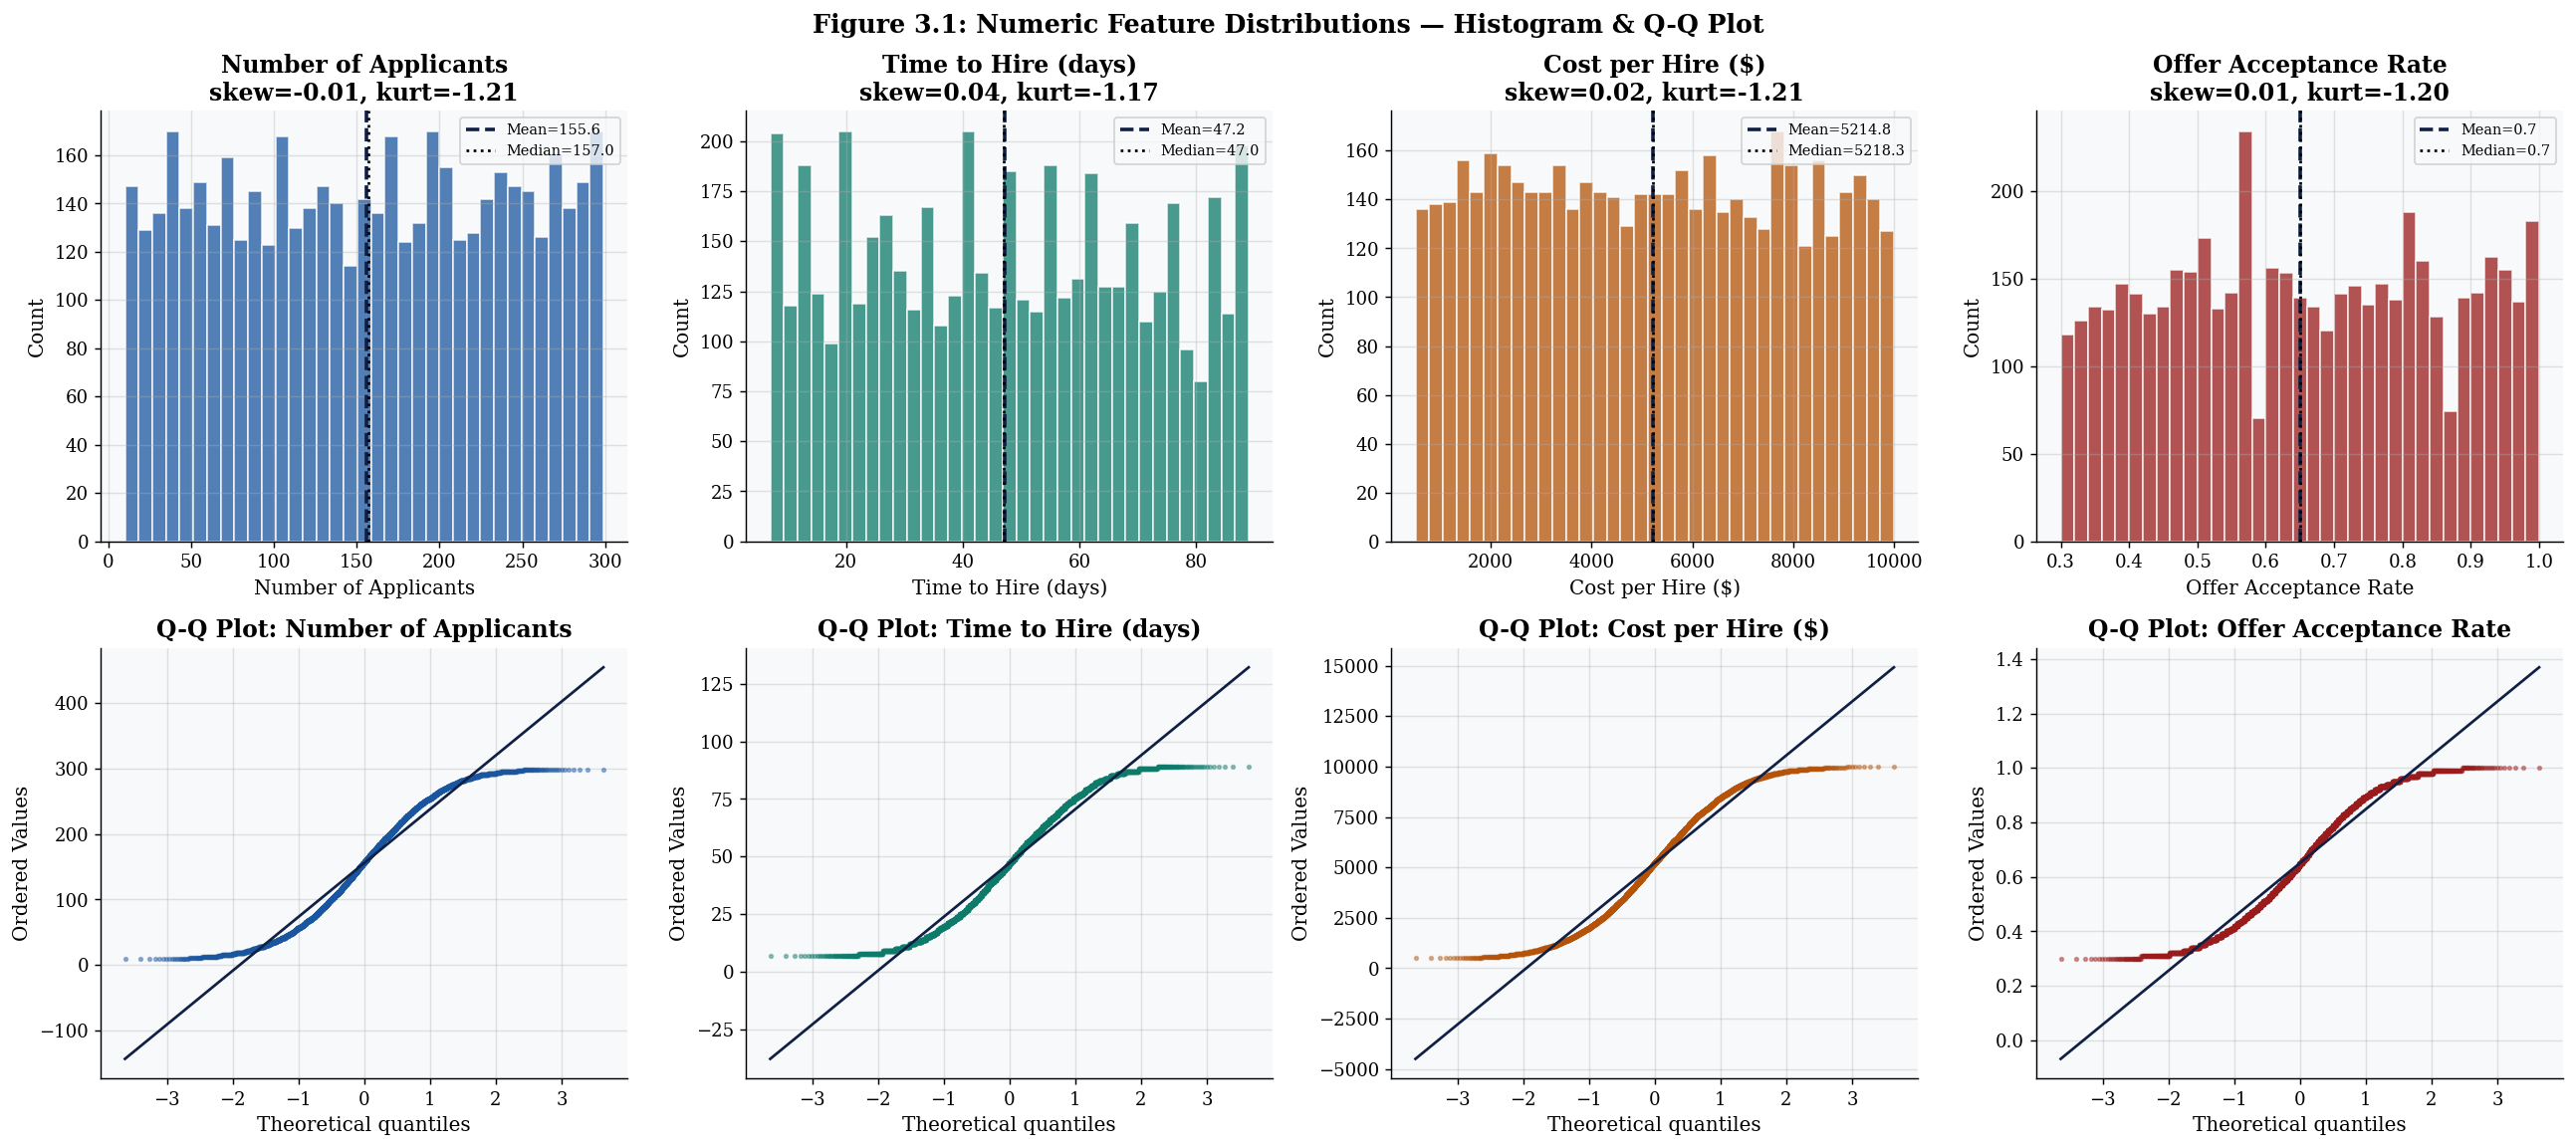

Insight: All four features display near-uniform distributions.
- Histograms show flat, even bars (no bell curve)
- Q-Q plots show S-curve deviations from normality (tails pull away from line)
- Skewness near 0 but kurtosis strongly negative (~-1.2) confirms platykurtic shape
- Business impact: mean-based statistics are reliable; normality-based tests are not


In [11]:
# Numeric Distribution Analysis
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Figure 3.1: Numeric Feature Distributions — Histogram & Q-Q Plot',
             fontweight='bold', fontsize=14)

plot_meta = [
    ('num_applicants',        C['blue'],  'Number of Applicants'),
    ('time_to_hire_days',     C['teal'],  'Time to Hire (days)'),
    ('cost_per_hire',         C['amber'], 'Cost per Hire ($)'),
    ('offer_acceptance_rate', C['red'],   'Offer Acceptance Rate'),
]

for i, (col, clr, label) in enumerate(plot_meta):
    # Histogram
    ax = axes[0, i]
    ax.hist(df[col], bins=35, color=clr, alpha=0.75, edgecolor='white')
    ax.axvline(df[col].mean(),   color=C['navy'], lw=2, linestyle='--', label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='black',   lw=1.5, linestyle=':', label=f'Median={df[col].median():.1f}')
    ax.set_title(f'{label}\nskew={df[col].skew():.2f}, kurt={df[col].kurt():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

    # Q-Q plot
    ax = axes[1, i]
    stats.probplot(df[col], plot=ax, dist='norm')
    ax.set_title(f'Q-Q Plot: {label}')
    ax.get_lines()[0].set(markersize=2, alpha=0.4, color=clr)
    ax.get_lines()[1].set(color=C['navy'], linewidth=1.5)

plt.tight_layout()
plt.savefig('fig_3.1_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

print('Insight: All four features display near-uniform distributions.')
print('- Histograms show flat, even bars (no bell curve)')
print('- Q-Q plots show S-curve deviations from normality (tails pull away from line)')
print('- Skewness near 0 but kurtosis strongly negative (~-1.2) confirms platykurtic shape')
print('- Business impact: mean-based statistics are reliable; normality-based tests are not')

## 3.3. Categorical Feature Analysis

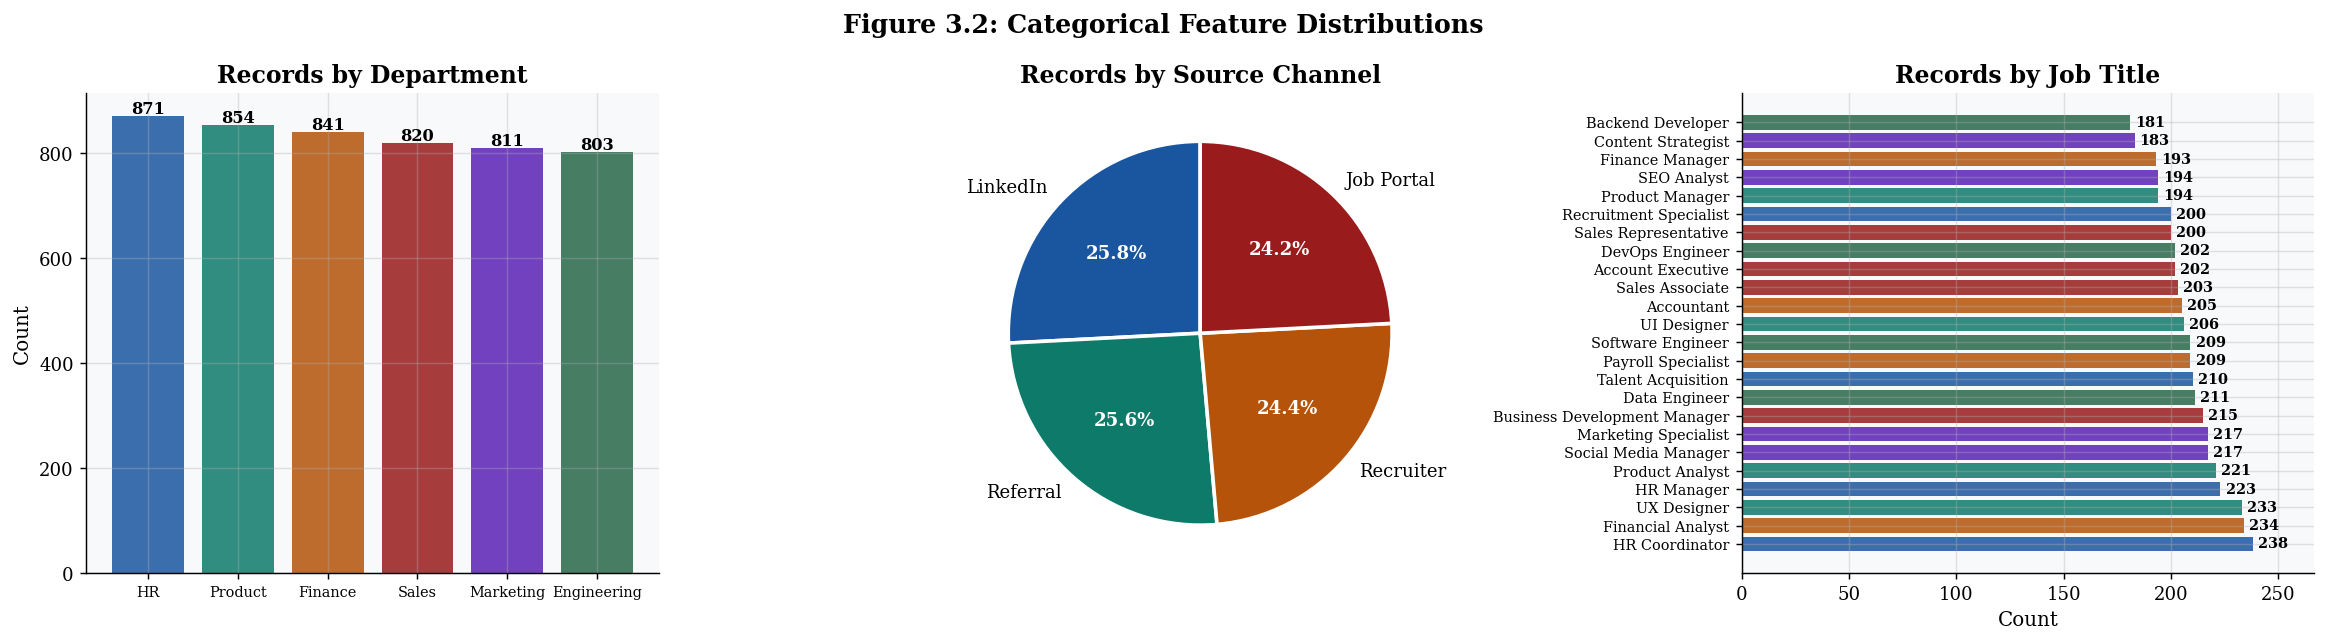

Insight:
- HR has most hires (871); Engineering has fewest (803)
- All 4 source channels are near-equally distributed (~24-26% each)
- HR Coordinator (238) and Backend Developer (181) have most/least records
- Even source channel distribution confirms no single channel dominates hiring strategy


In [12]:
# Categorical Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 3.2: Categorical Feature Distributions',
             fontweight='bold', fontsize=14)

# Department
ax = axes[0]
dept_counts = df['department'].value_counts()
bars = ax.bar(dept_counts.index, dept_counts.values, color=DEPT_COLORS, alpha=0.85)
ax.set_title('Records by Department')
ax.set_ylabel('Count')
ax.set_xticklabels(dept_counts.index, fontsize=8)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
            f'{int(b.get_height()):,}', ha='center', fontsize=9, fontweight='bold')

# Source
ax = axes[1]
src_counts = df['source'].value_counts()
wedges, texts, autotexts = ax.pie(
    src_counts.values, labels=src_counts.index,
    autopct='%1.1f%%', colors=SRC_COLORS,
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
    t.set_color('white')
ax.set_title('Records by Source Channel')

# Job Title
ax = axes[2]
jt_counts = df['job_title'].value_counts()

# Map each job title to its most common department, then to DEPT_COLORS
jt_dept = df.groupby('job_title')['department'].agg(lambda x: x.value_counts().idxmax())
dept_color_map = dict(zip(dept_counts.index, DEPT_COLORS))
bar_colors = [dept_color_map.get(jt_dept.get(jt), C['blue']) for jt in jt_counts.index]

bars_h = ax.barh(jt_counts.index, jt_counts.values, color=bar_colors, alpha=0.85)
ax.set_title('Records by Job Title')
ax.set_xlabel('Count')
ax.tick_params(axis='y', labelsize=8)

# Add value count labels to the right of each bar  ← new
x_max = jt_counts.max()
for b in bars_h:
    ax.text(b.get_width() + x_max * 0.01, b.get_y() + b.get_height() / 2,
            f'{int(b.get_width()):,}', va='center', fontsize=8, fontweight='bold')

# Give a little extra right margin so labels don't clip
ax.set_xlim(right=x_max * 1.12)

plt.tight_layout()
plt.savefig('fig_3.2_categorical.png', bbox_inches='tight', dpi=150)
plt.show()

print('Insight:')
print(f'- HR has most hires ({dept_counts.max():,}); Engineering has fewest ({dept_counts.min():,})')
print(f'- All 4 source channels are near-equally distributed (~24-26% each)')
print(f'- HR Coordinator ({jt_counts.max():,}) and Backend Developer ({jt_counts.min():,}) have most/least records')
print('- Even source channel distribution confirms no single channel dominates hiring strategy')

## 3.4. KPI Metrics — Benchmarked

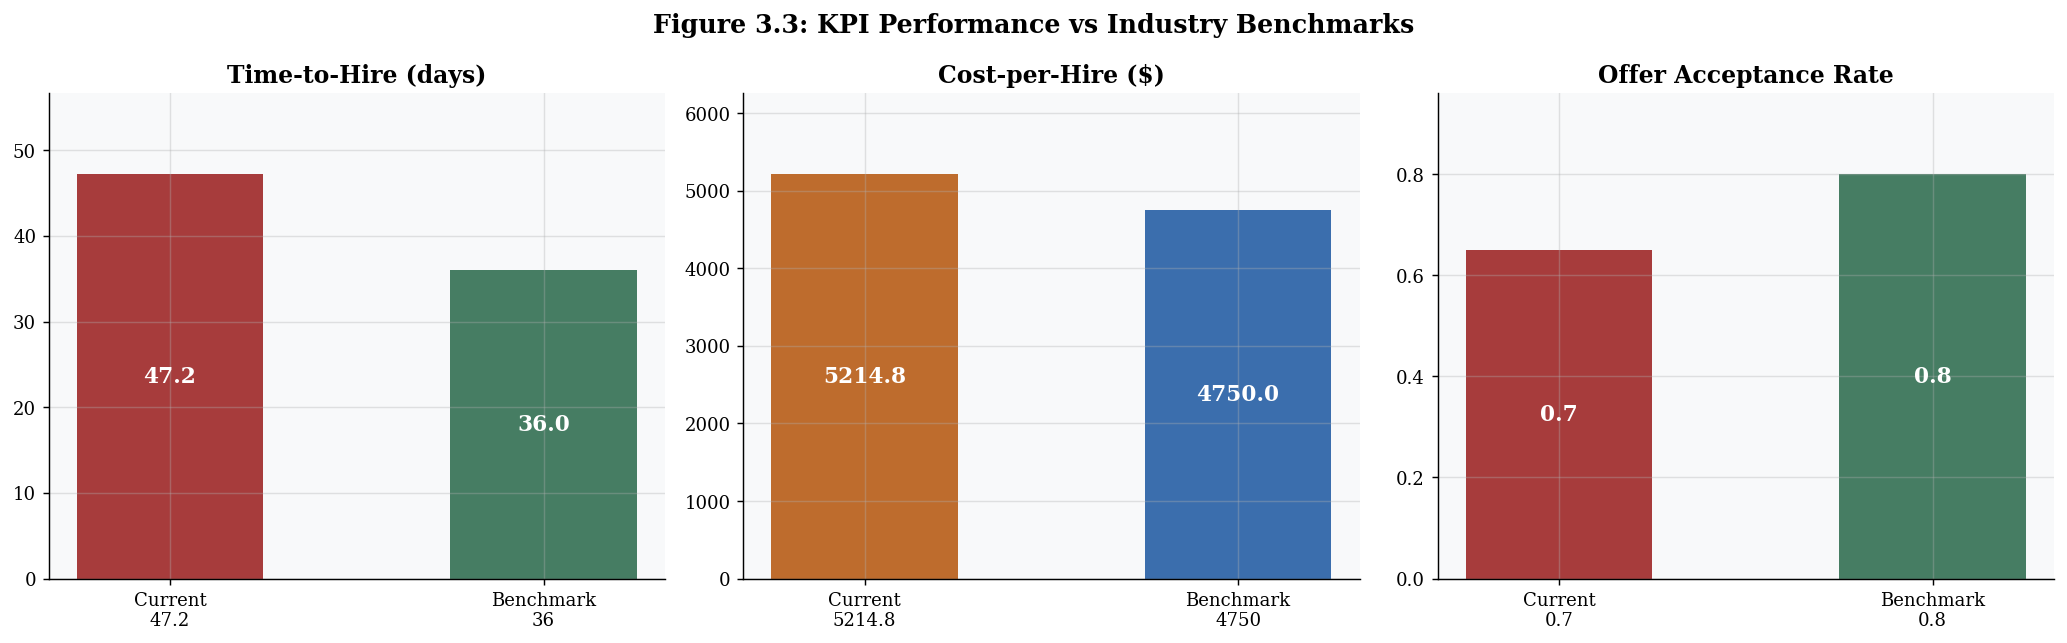

Key findings:
Time-to-Hire : 47.2 days (target ≤36)     → +11.2d gap
Cost/Hire    : $5,215    (target $4,750)  → +$465 gap
OAR          : 65.1%     (target ≥80%)    → -14.9pp gap


In [13]:
# KPI Benchmarking
benchmarks = {
    'time_to_hire_days'     : {'val': 36,    'label': 'LinkedIn Report: 36d',    'unit': 'days'},
    'cost_per_hire'         : {'val': 4750,  'label': 'SHRM Benchmark: $4,750',  'unit': 'USD'},
    'offer_acceptance_rate' : {'val': 0.80,  'label': 'KPI Depot: 80%',          'unit': '%'},
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 3.3: KPI Performance vs Industry Benchmarks',
             fontweight='bold', fontsize=14)

kpi_meta = [
    ('time_to_hire_days',     'Time-to-Hire (days)',    C['red'],   C['green']),
    ('cost_per_hire',         'Cost-per-Hire ($)',      C['amber'], C['blue']),
    ('offer_acceptance_rate', 'Offer Acceptance Rate',  C['red'],   C['green']),
]

for ax, (col, label, cur_clr, bench_clr) in zip(axes, kpi_meta):
    cur_val   = df[col].mean()
    bench_val = benchmarks[col]['val']
    bench_lbl = benchmarks[col]['label']

    vals  = [cur_val, bench_val]
    lbls  = [f'Current\n{cur_val:.1f}', f'Benchmark\n{bench_val}']
    clrs  = [cur_clr, bench_clr]
    bars  = ax.bar(lbls, vals, color=clrs, alpha=0.85, width=0.5)

    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*0.5,
                f'{v:.1f}', ha='center', va='center',
                fontweight='bold', fontsize=12, color='white')

    ax.set_title(label)
    ax.set_ylim(0, max(vals)*1.2)

plt.tight_layout()
plt.savefig('fig_3.3_kpi_benchmarks.png', bbox_inches='tight', dpi=150)
plt.show()

print('Key findings:')
print(f'Time-to-Hire : {df["time_to_hire_days"].mean():.1f} days (target ≤36)     → +{df["time_to_hire_days"].mean()-36:.1f}d gap')
print(f'Cost/Hire    : ${df["cost_per_hire"].mean():,.0f}    (target $4,750)  → +${df["cost_per_hire"].mean()-4750:,.0f} gap')
print(f'OAR          : {df["offer_acceptance_rate"].mean()*100:.1f}%     (target ≥80%)    → -{(0.80-df["offer_acceptance_rate"].mean())*100:.1f}pp gap')

## 3.5. Performance by Department and Source

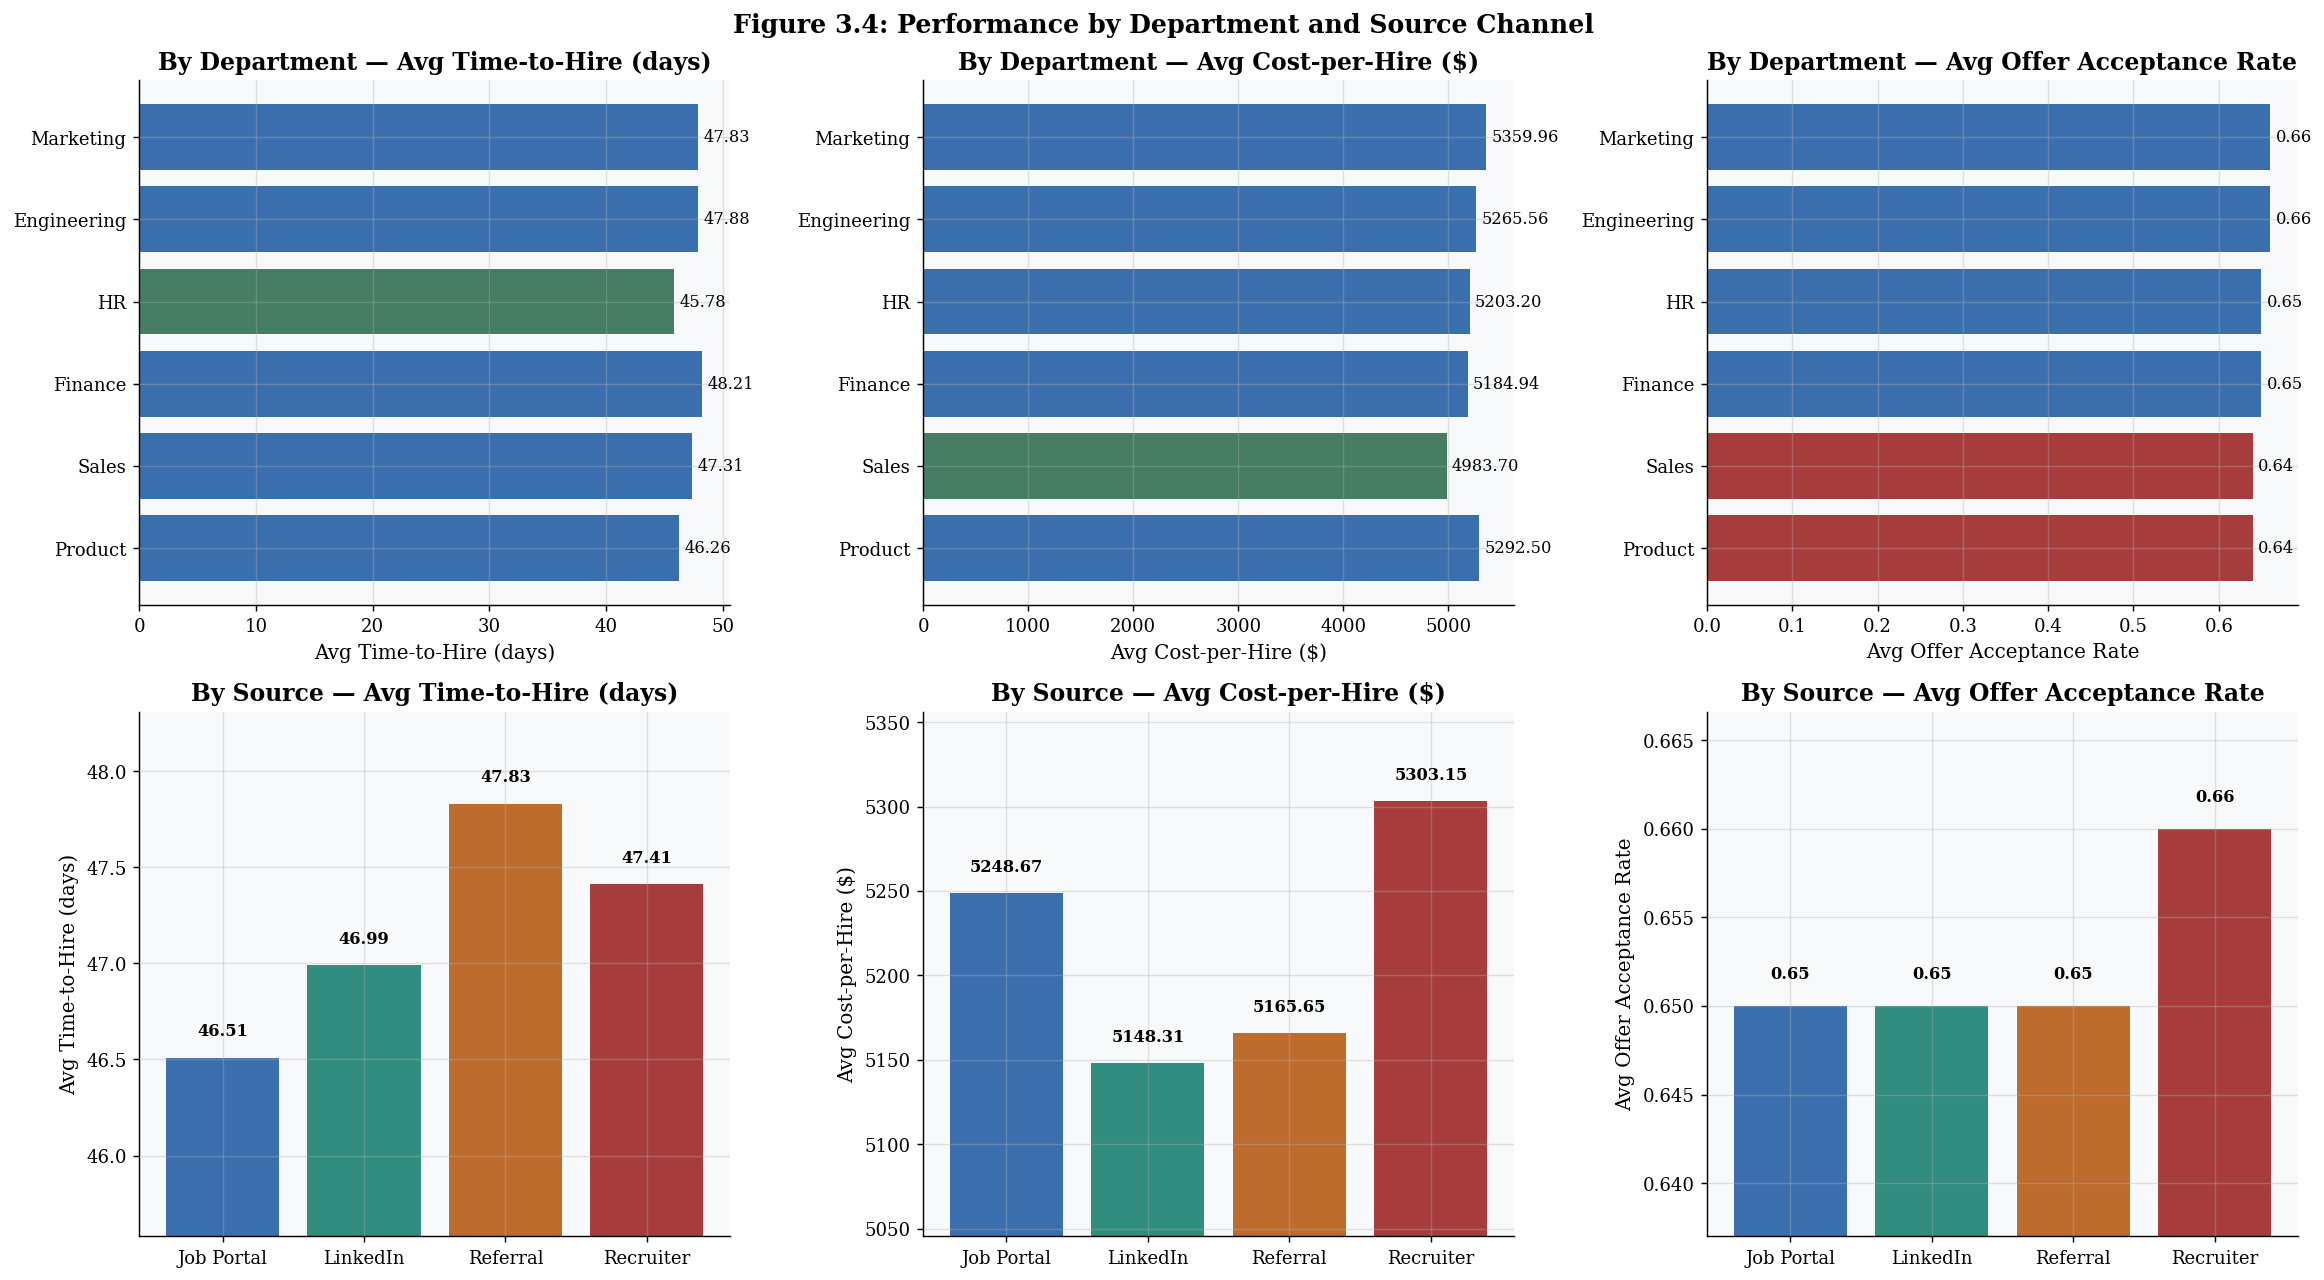

Key findings:
Worst OAR dept  : Product (0.640)
Best  OAR dept  : Engineering (0.660)
Slowest dept    : Finance (48.2d)
Most expensive  : Marketing ($5,360)
OAR range (src) : 0.0100 (1.00pp)
→ Near-identical source performance confirms systemic, not channel-specific root cause


In [14]:
# Department & Source Performance
dept_perf = df.groupby('department', observed=True).agg(
    count          = ('recruitment_id', 'count'),
    avg_tth        = ('time_to_hire_days', 'mean'),
    avg_cost       = ('cost_per_hire', 'mean'),
    avg_oar        = ('offer_acceptance_rate', 'mean'),
).round(2).sort_values('avg_oar')

src_perf = df.groupby('source', observed=True).agg(
    count    = ('recruitment_id', 'count'),
    avg_tth  = ('time_to_hire_days', 'mean'),
    avg_cost = ('cost_per_hire', 'mean'),
    avg_oar  = ('offer_acceptance_rate', 'mean'),
).round(2).sort_values('avg_oar')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 3.4: Performance by Department and Source Channel',
             fontweight='bold', fontsize=14)

metrics = [('avg_tth','Avg Time-to-Hire (days)'),
           ('avg_cost','Avg Cost-per-Hire ($)'),
           ('avg_oar','Avg Offer Acceptance Rate')]

for col_idx, (metric, ylabel) in enumerate(metrics):
    # Department
    ax = axes[0, col_idx]
    clrs = [C['green'] if v == dept_perf[metric].min() else C['blue'] for v in dept_perf[metric]]
    if metric == 'avg_oar':
        clrs = [C['red'] if v == dept_perf[metric].min() else C['blue'] for v in dept_perf[metric]]
    ax.barh(dept_perf.index, dept_perf[metric], color=clrs, alpha=0.85)
    ax.set_title(f'By Department — {ylabel}')
    ax.set_xlabel(ylabel)
    for i, v in enumerate(dept_perf[metric]):
        ax.text(v+abs(v)*0.01, i, f'{v:.2f}', va='center', fontsize=9)

    # Source
    ax = axes[1, col_idx]
    bars = ax.bar(src_perf.index, src_perf[metric], color=SRC_COLORS, alpha=0.85)
    ax.set_title(f'By Source — {ylabel}')
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(src_perf.index)
    ylim_min = src_perf[metric].min() * 0.98
    ylim_max = src_perf[metric].max() * 1.01
    ax.set_ylim(ylim_min, ylim_max)

    # Value labels above each bar
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + abs(b.get_height()) * 0.002,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_3.4_dept_source_perf.png', bbox_inches='tight', dpi=150)
plt.show()

print('Key findings:')
print(f'Worst OAR dept  : {dept_perf["avg_oar"].idxmin()} ({dept_perf["avg_oar"].min():.3f})')
print(f'Best  OAR dept  : {dept_perf["avg_oar"].idxmax()} ({dept_perf["avg_oar"].max():.3f})')
print(f'Slowest dept    : {dept_perf["avg_tth"].idxmax()} ({dept_perf["avg_tth"].max():.1f}d)')
print(f'Most expensive  : {dept_perf["avg_cost"].idxmax()} (${dept_perf["avg_cost"].max():,.0f})')
print(f'OAR range (src) : {src_perf["avg_oar"].max()-src_perf["avg_oar"].min():.4f} ({(src_perf["avg_oar"].max()-src_perf["avg_oar"].min())*100:.2f}pp)')
print('→ Near-identical source performance confirms systemic, not channel-specific root cause')

## 3.6. Department × Source Heatmap

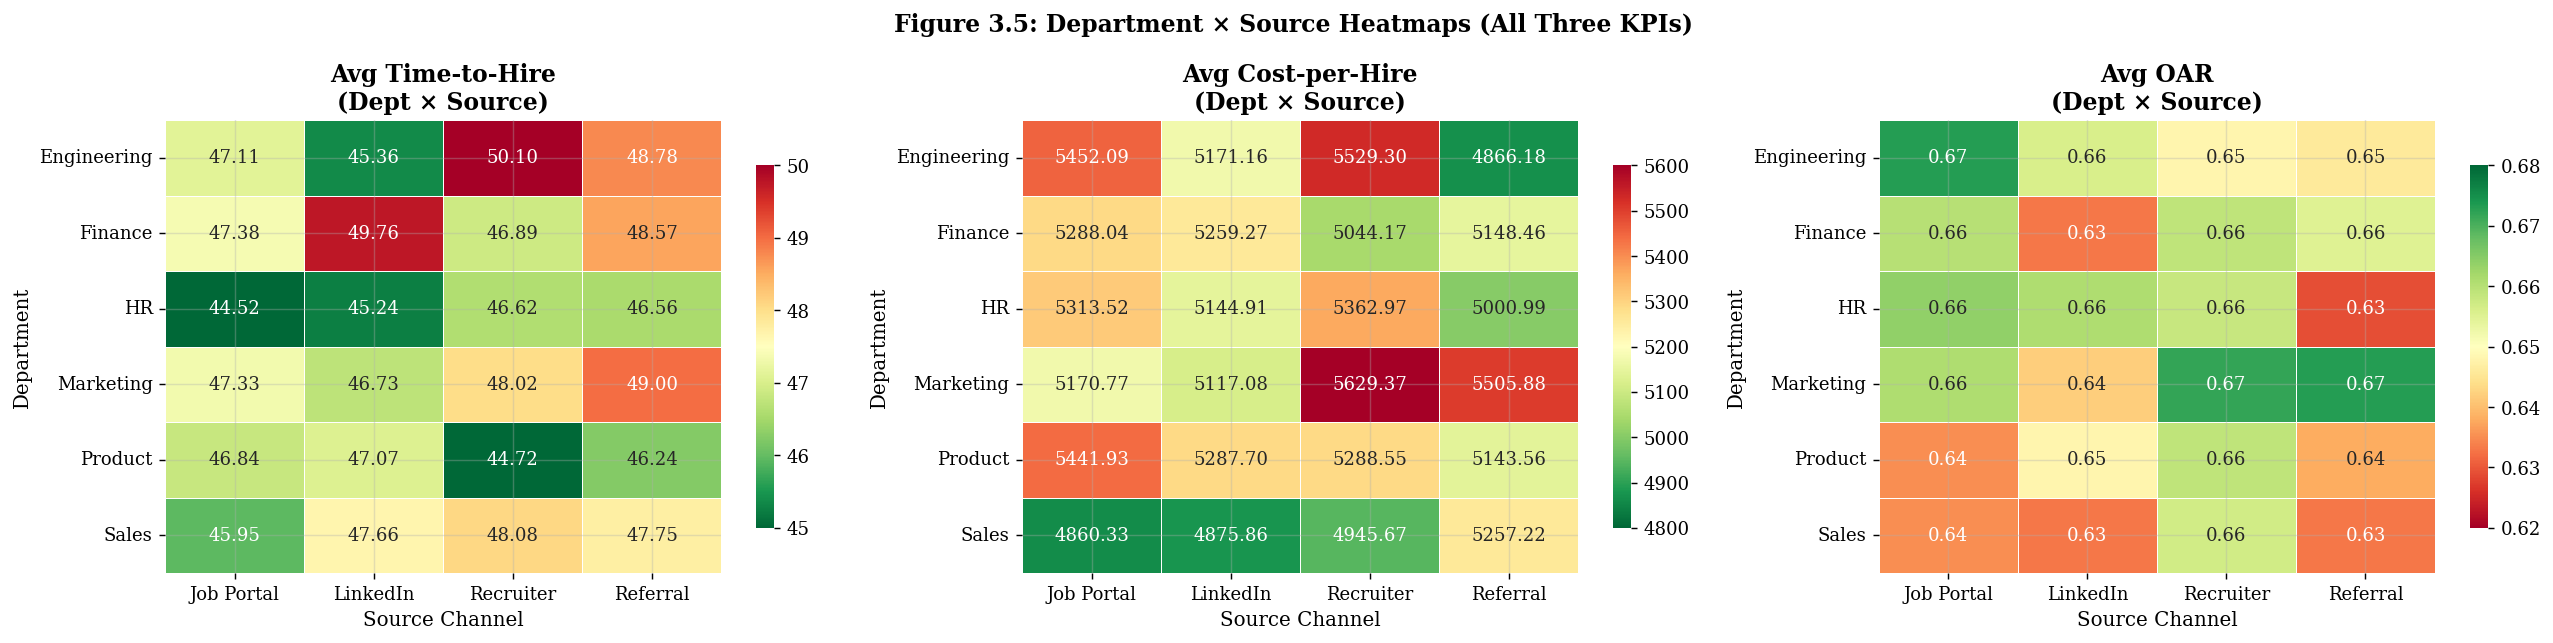

Insight:
Heatmap color variation across all three KPIs is minimal.
No single department-source combination stands out as best or worst.
This confirms: the problem is systemic across the organisation, not isolated to a specific sourcing channel or department process.


In [15]:
# Department × Source Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Figure 3.5: Department × Source Heatmaps (All Three KPIs)',
             fontweight='bold', fontsize=13)

heatmap_configs = [
    ('time_to_hire_days',     'Avg Time-to-Hire',  'RdYlGn_r', 45, 50),
    ('cost_per_hire',         'Avg Cost-per-Hire', 'RdYlGn_r', 4800, 5600),
    ('offer_acceptance_rate', 'Avg OAR',           'RdYlGn', 0.62, 0.68),
]

for ax, (col, title, cmap, vmin, vmax) in zip(axes, heatmap_configs):
    pivot = df.groupby(['department','source'], observed=True)[col].mean().unstack().round(3)
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap=cmap,
                vmin=vmin, vmax=vmax, ax=ax,
                linewidths=0.5, linecolor='white',
                cbar_kws={'shrink':0.8})
    ax.set_title(f'{title}\n(Dept × Source)', fontweight='bold')
    ax.set_xlabel('Source Channel')
    ax.set_ylabel('Department')

plt.tight_layout()
plt.savefig('fig_3.5_heatmaps.png', bbox_inches='tight', dpi=150)
plt.show()

print('Insight:')
print('Heatmap color variation across all three KPIs is minimal.')
print('No single department-source combination stands out as best or worst.')
print('This confirms: the problem is systemic across the organisation, not isolated to a specific sourcing channel or department process.')

## 3.7. Job Title Analysis

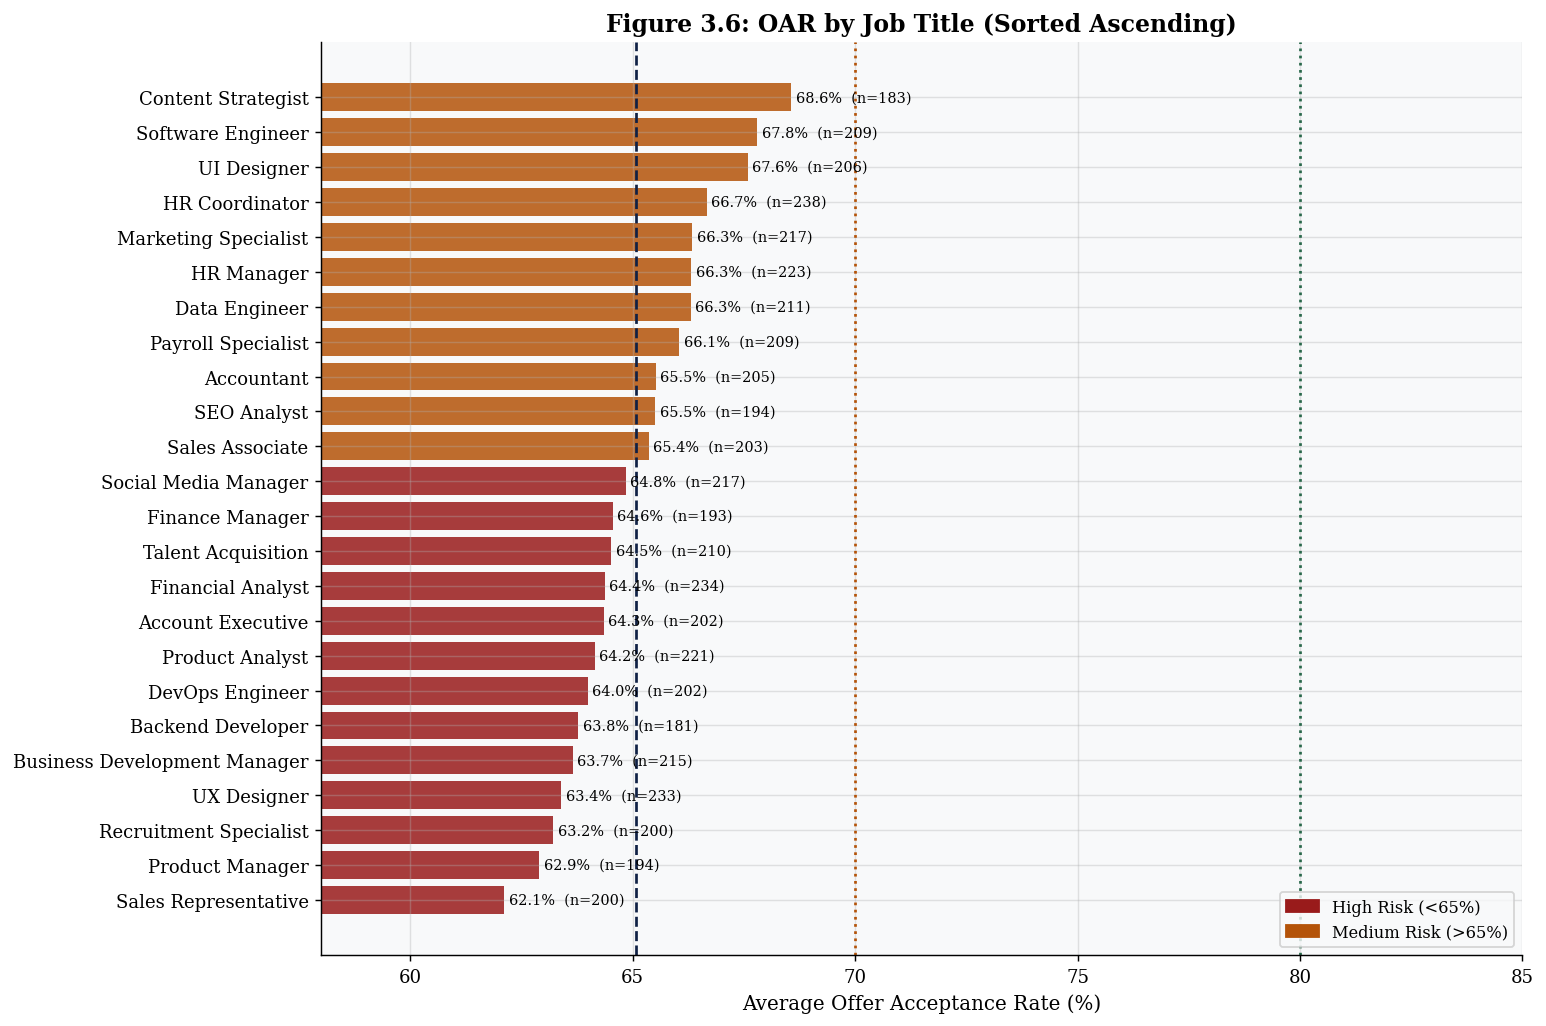

High-risk roles (OAR < 65%):
- Sales Representative                OAR=62.1%  (n=200)
- Product Manager                     OAR=62.9%  (n=194)
- Recruitment Specialist              OAR=63.2%  (n=200)
- UX Designer                         OAR=63.4%  (n=233)
- Business Development Manager        OAR=63.7%  (n=215)
- Backend Developer                   OAR=63.8%  (n=181)
- DevOps Engineer                     OAR=64.0%  (n=202)
- Product Analyst                     OAR=64.2%  (n=221)
- Account Executive                   OAR=64.3%  (n=202)
- Financial Analyst                   OAR=64.4%  (n=234)
- Talent Acquisition                  OAR=64.5%  (n=210)
- Finance Manager                     OAR=64.6%  (n=193)
- Social Media Manager                OAR=64.8%  (n=217)


In [16]:
# Job Title OAR Analysis 
jt_oar = df.groupby('job_title', observed=True)['offer_acceptance_rate'].agg(['mean','std','count']).sort_values('mean')
jt_oar['mean_pct'] = jt_oar['mean'] * 100

fig, ax = plt.subplots(figsize=(12, 8))
clrs = [C['red'] if v < 0.65 else C['amber']
        for v in jt_oar['mean']]
ax.barh(jt_oar.index, jt_oar['mean_pct'], color=clrs, alpha=0.85)
ax.axvline(df['offer_acceptance_rate'].mean()*100, color=C['navy'],
           linestyle='--', lw=1.5, label=f'Overall Mean: {df["offer_acceptance_rate"].mean()*100:.1f}%')
ax.axvline(80, color=C['green'], linestyle=':', lw=1.5, label='Industry Target: 80%')
ax.axvline(70, color=C['amber'], linestyle=':', lw=1.5, label='Red-flag: 70%')

for i, (idx, row) in enumerate(jt_oar.iterrows()):
    ax.text(row['mean_pct']+0.1, i, f'{row["mean_pct"]:.1f}%  (n={int(row["count"])})',
            va='center', fontsize=8)

ax.set_xlabel('Average Offer Acceptance Rate (%)')
ax.set_title('Figure 3.6: OAR by Job Title (Sorted Ascending)', fontweight='bold')
ax.set_xlim(58, 85)
ax.legend(fontsize=9)

red_patch   = mpatches.Patch(color=C['red'],   label='High Risk (<65%)')
amber_patch = mpatches.Patch(color=C['amber'], label='Medium Risk (>65%)')
ax.legend(handles=[red_patch,amber_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('fig_3.6_jobtitle_oar.png', bbox_inches='tight', dpi=150)
plt.show()

print('High-risk roles (OAR < 65%):')
for idx, row in jt_oar[jt_oar['mean'] < 0.65].iterrows():
    print(f'- {idx:<35} OAR={row["mean_pct"]:.1f}%  (n={int(row["count"])})')

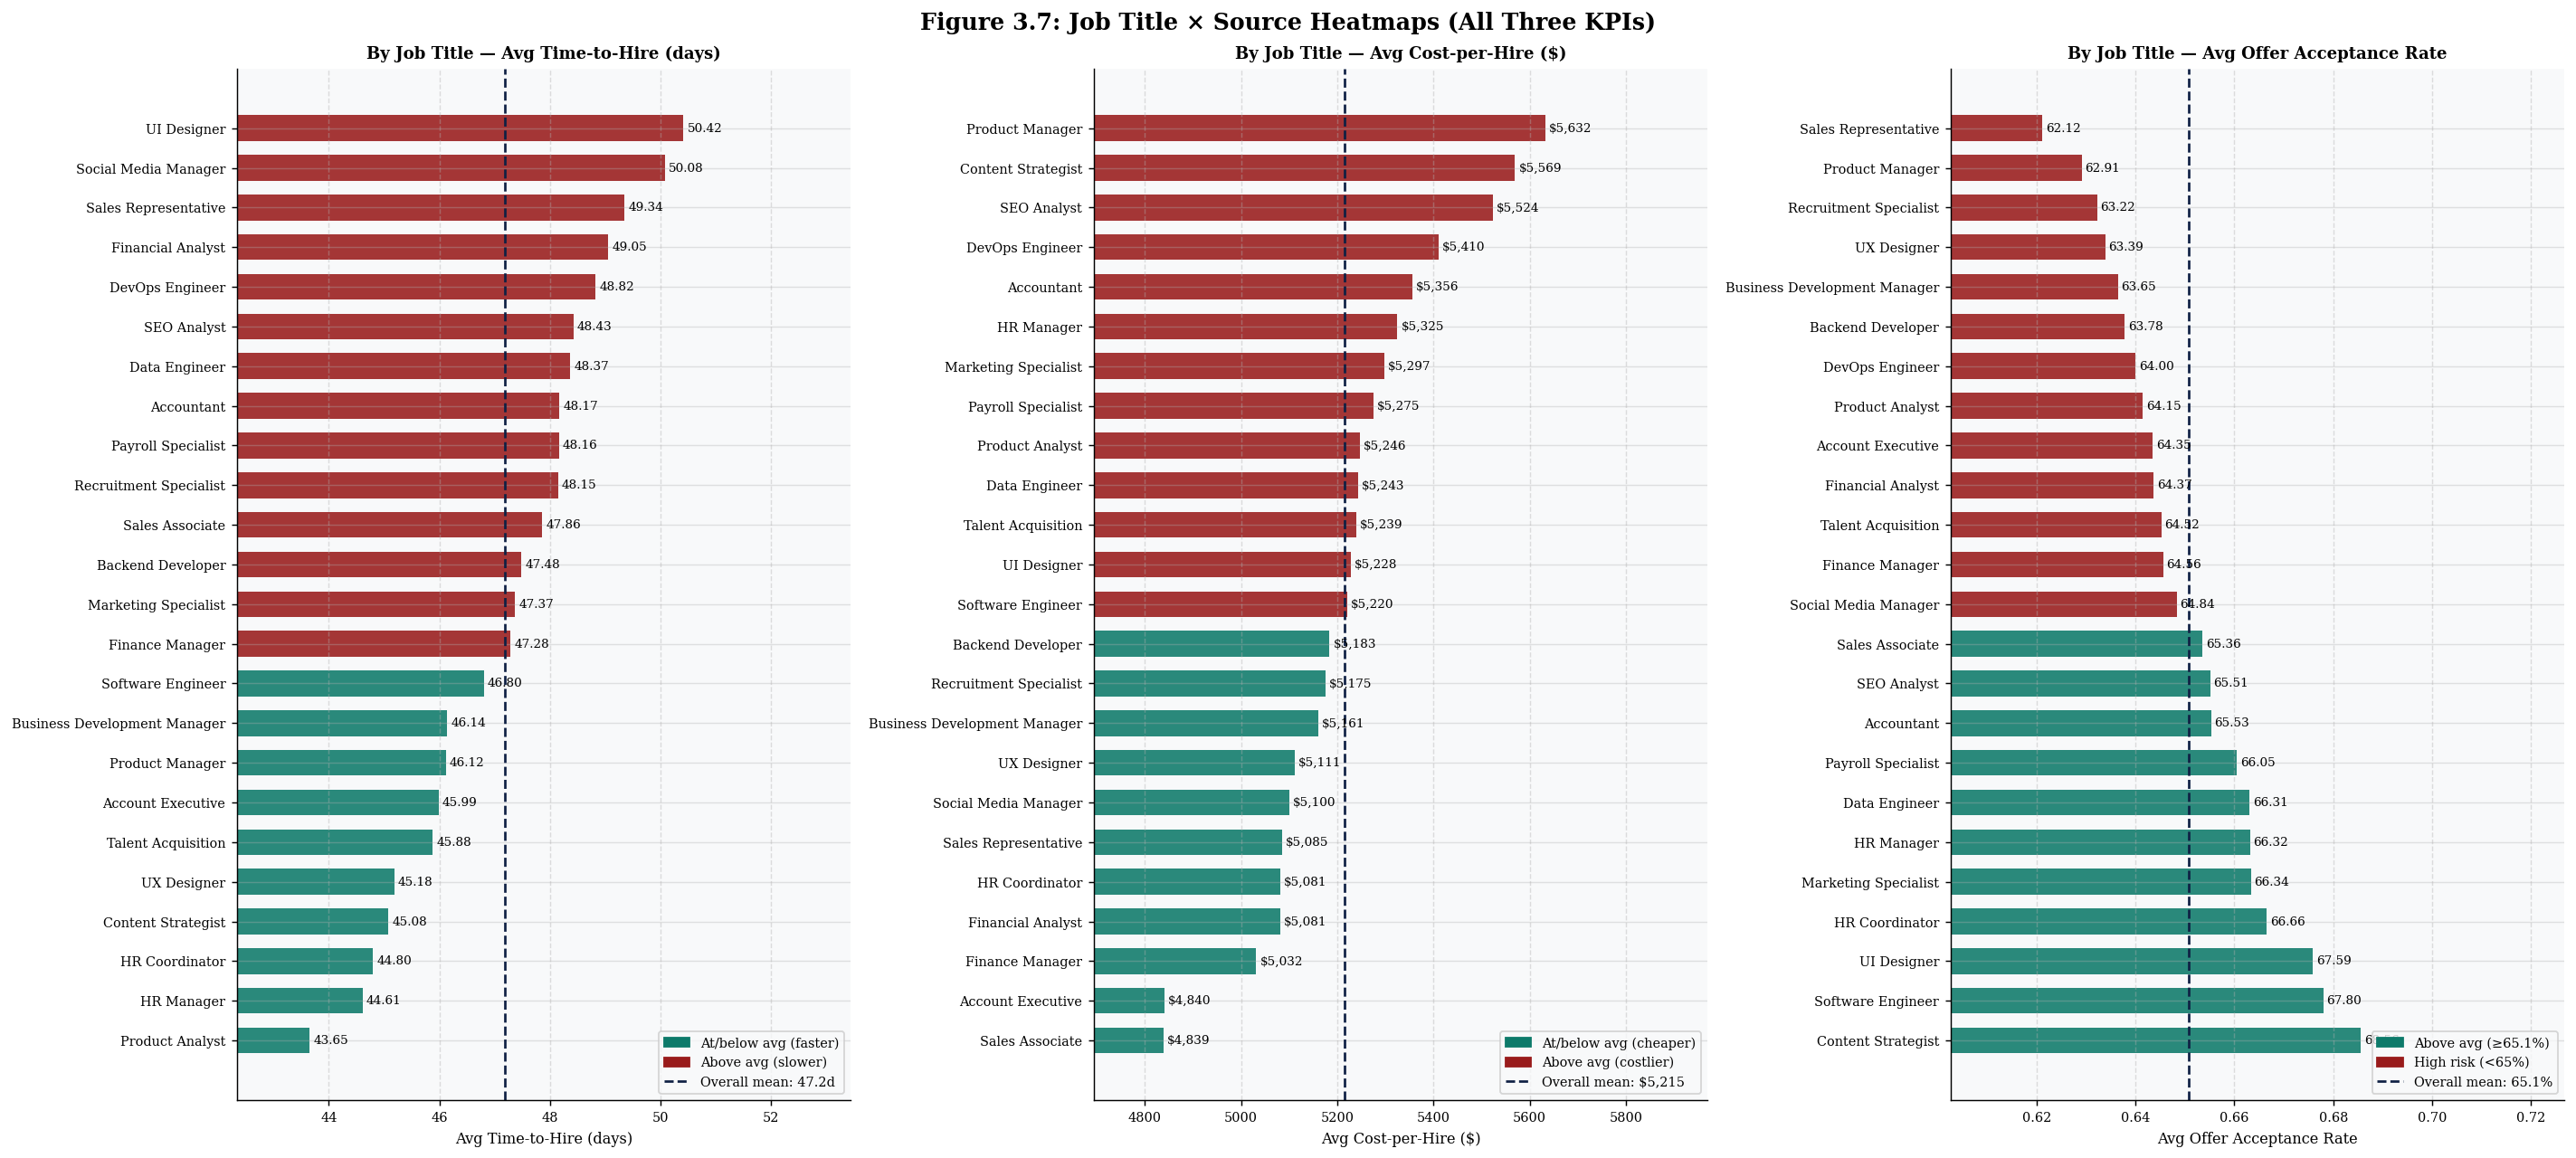

Slowest to hire (TTH > overall mean)
- UI Designer                         50.4 days
- Social Media Manager                50.1 days
- Sales Representative                49.3 days
- Financial Analyst                   49.1 days
- DevOps Engineer                     48.8 days
- SEO Analyst                         48.4 days
- Data Engineer                       48.4 days
- Accountant                          48.2 days
- Payroll Specialist                  48.2 days
- Recruitment Specialist              48.1 days
- Sales Associate                     47.9 days
- Backend Developer                   47.5 days
- Marketing Specialist                47.4 days
- Finance Manager                     47.3 days

Most expensive (CPH > overall mean)
- Product Manager                     $5,632
- Content Strategist                  $5,569
- SEO Analyst                         $5,524
- DevOps Engineer                     $5,410
- Accountant                          $5,356
- HR Manager                 

In [17]:
jt = (
    df.groupby('job_title', observed=True)
    .agg(
        tth=('time_to_hire_days',    'mean'),
        cph=('cost_per_hire',        'mean'),
        oar=('offer_acceptance_rate','mean'),
    )
    .round(4)
)
 
overall_tth = df['time_to_hire_days'].mean()
overall_cph = df['cost_per_hire'].mean()
overall_oar = df['offer_acceptance_rate'].mean()
 
# Helper: colour by threshold
def tth_colors(series):
    """Green = faster than avg (good), Red = slower than avg (bad)."""
    return [C['teal'] if v <= overall_tth else C['red'] for v in series]
 
def cph_colors(series):
    """Green = cheaper than avg (good), Red = more expensive (bad)."""
    return [C['teal'] if v <= overall_cph else C['red'] for v in series]
 
def oar_colors(series):
    """Green = above avg (good), Red = below 65% (high risk), Amber = 65–avg."""
    out = []
    for v in series:
        if v < 0.65:
            out.append(C['red'])
        elif v < overall_oar:
            out.append(C['amber'])
        else:
            out.append(C['teal'])
    return out
 
# Figure layout
fig, axes = plt.subplots(1, 3, figsize=(22, 10))
fig.suptitle(
    'Figure 3.7: Job Title × Source Heatmaps (All Three KPIs)',
    fontweight='bold', fontsize=14
)
 
configs = [
    # (sort_ascending, data_col, colors_fn, xlabel, title, overall_val, vline_label, fmt)
    (True,  'tth', tth_colors, 'Avg Time-to-Hire (days)',
     'By Job Title — Avg Time-to-Hire (days)', overall_tth,
     f'Overall Mean: {overall_tth:.1f} days', '{:.2f}'),
 
    (True,  'cph', cph_colors, 'Avg Cost-per-Hire ($)',
     'By Job Title — Avg Cost-per-Hire ($)',   overall_cph,
     f'Overall Mean: ${overall_cph:,.0f}',     '${:,.0f}'),
 
    (False, 'oar', oar_colors, 'Avg Offer Acceptance Rate',
     'By Job Title — Avg Offer Acceptance Rate', overall_oar,
     f'Overall Mean: {overall_oar*100:.1f}%',  '{:.2f}'),
]
 
for ax, (asc, col, color_fn, xlabel, title, overall, vline_lbl, fmt) in zip(axes, configs):
    sub = jt[[col]].sort_values(col, ascending=asc)
    vals = sub[col]
    labels = sub.index.tolist()
    colors = color_fn(vals)
 
    bars = ax.barh(labels, vals, color=colors, alpha=0.88, height=0.65)
 
    # Overall mean vline
    ax.axvline(overall, color=C['navy'], linestyle='--', lw=1.5, label=vline_lbl)
 
    # Value annotations
    x_range = vals.max() - vals.min()
    for bar, v in zip(bars, vals):
        label = fmt.format(v * 100 if col == 'oar' else v)
        ax.text(
            v + x_range * 0.01,
            bar.get_y() + bar.get_height() / 2,
            label, va='center', ha='left', fontsize=7.5
        )
 
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlim(vals.min() * 0.97, vals.max() * 1.06)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.spines[['top','right']].set_visible(False)
 
# Legends
# TTH
axes[0].legend(
    handles=[
        mpatches.Patch(color=C['teal'], label='At/below avg (faster)'),
        mpatches.Patch(color=C['red'],  label='Above avg (slower)'),
        plt.Line2D([0],[0], color=C['navy'], ls='--', lw=1.5, label=f'Overall mean: {overall_tth:.1f}d'),
    ],
    fontsize=8, loc='lower right'
)
# CPH
axes[1].legend(
    handles=[
        mpatches.Patch(color=C['teal'], label='At/below avg (cheaper)'),
        mpatches.Patch(color=C['red'],  label='Above avg (costlier)'),
        plt.Line2D([0],[0], color=C['navy'], ls='--', lw=1.5, label=f'Overall mean: ${overall_cph:,.0f}'),
    ],
    fontsize=8, loc='lower right'
)
# OAR
axes[2].legend(
    handles=[
        mpatches.Patch(color=C['teal'],  label=f'Above avg (≥{overall_oar*100:.1f}%)'),
        mpatches.Patch(color=C['red'],   label='High risk (<65%)'),
        plt.Line2D([0],[0], color=C['navy'], ls='--', lw=1.5, label=f'Overall mean: {overall_oar*100:.1f}%'),
    ],
    fontsize=8, loc='lower right'
)
 
plt.tight_layout()
plt.savefig('fig_3.7_jobtitle_3kpi.png', bbox_inches='tight', dpi=150)
plt.show()
 
# Console insights
print('Slowest to hire (TTH > overall mean)')
for idx, row in jt[jt['tth'] > overall_tth].sort_values('tth', ascending=False).iterrows():
    print(f'- {idx:<35} {row["tth"]:.1f} days')
 
print('\nMost expensive (CPH > overall mean)')
for idx, row in jt[jt['cph'] > overall_cph].sort_values('cph', ascending=False).iterrows():
    print(f'- {idx:<35} ${row["cph"]:,.0f}')
 
print('\nHigh-risk OAR (< 65%)')
for idx, row in jt[jt['oar'] < 0.65].sort_values('oar').iterrows():
    print(f'-{idx:<36} OAR={row["oar"]*101:.1f}%')

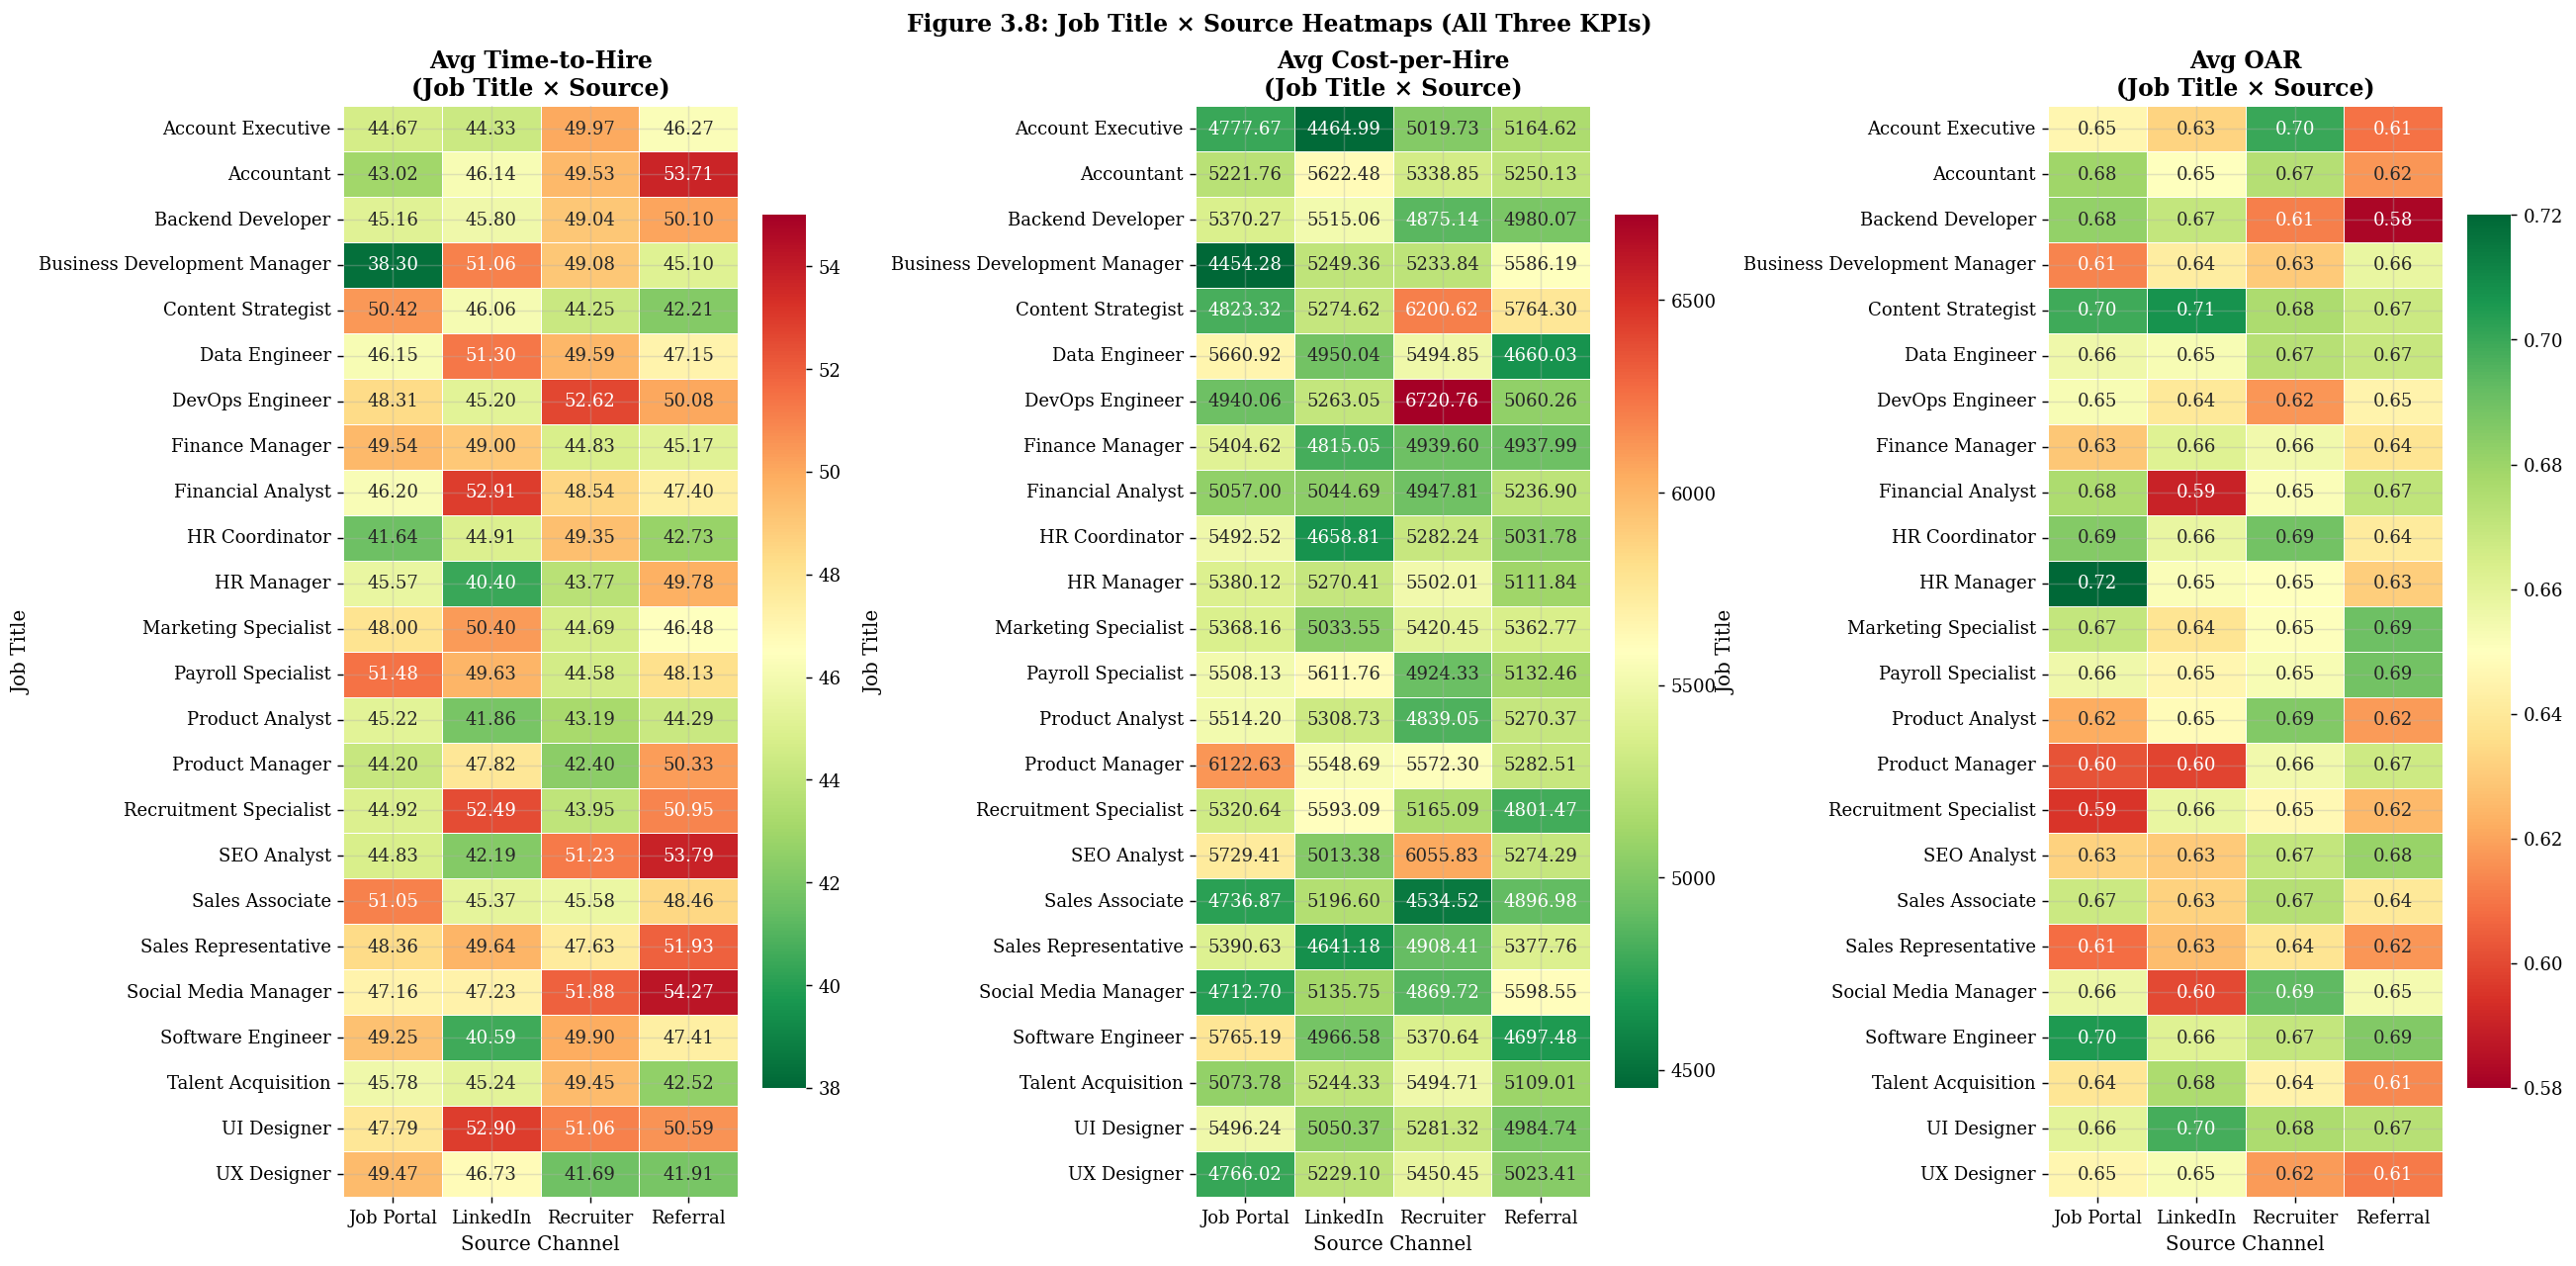

In [18]:
# Department × Source Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
fig.suptitle('Figure 3.8: Job Title × Source Heatmaps (All Three KPIs)',
             fontweight='bold', fontsize=13)

heatmap_configs = [
    ('time_to_hire_days',     'Avg Time-to-Hire',  'RdYlGn_r', 38, 55),
    ('cost_per_hire',         'Avg Cost-per-Hire', 'RdYlGn_r', 4454, 6721),
    ('offer_acceptance_rate', 'Avg OAR',           'RdYlGn', 0.58, 0.72),
]

for ax, (col, title, cmap, vmin, vmax) in zip(axes, heatmap_configs):
    pivot = df.groupby(['job_title','source'], observed=True)[col].mean().unstack().round(3)
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap=cmap,
                vmin=vmin, vmax=vmax, ax=ax,
                linewidths=0.5, linecolor='white',
                cbar_kws={'shrink':0.8})
    ax.set_title(f'{title}\n(Job Title × Source)', fontweight='bold')
    ax.set_xlabel('Source Channel')
    ax.set_ylabel('Job Title')

plt.tight_layout()
plt.savefig('fig_3.8_heatmaps.png', bbox_inches='tight', dpi=150)
plt.show()

## 3.8. Correlation & Feature Relationship Analysis

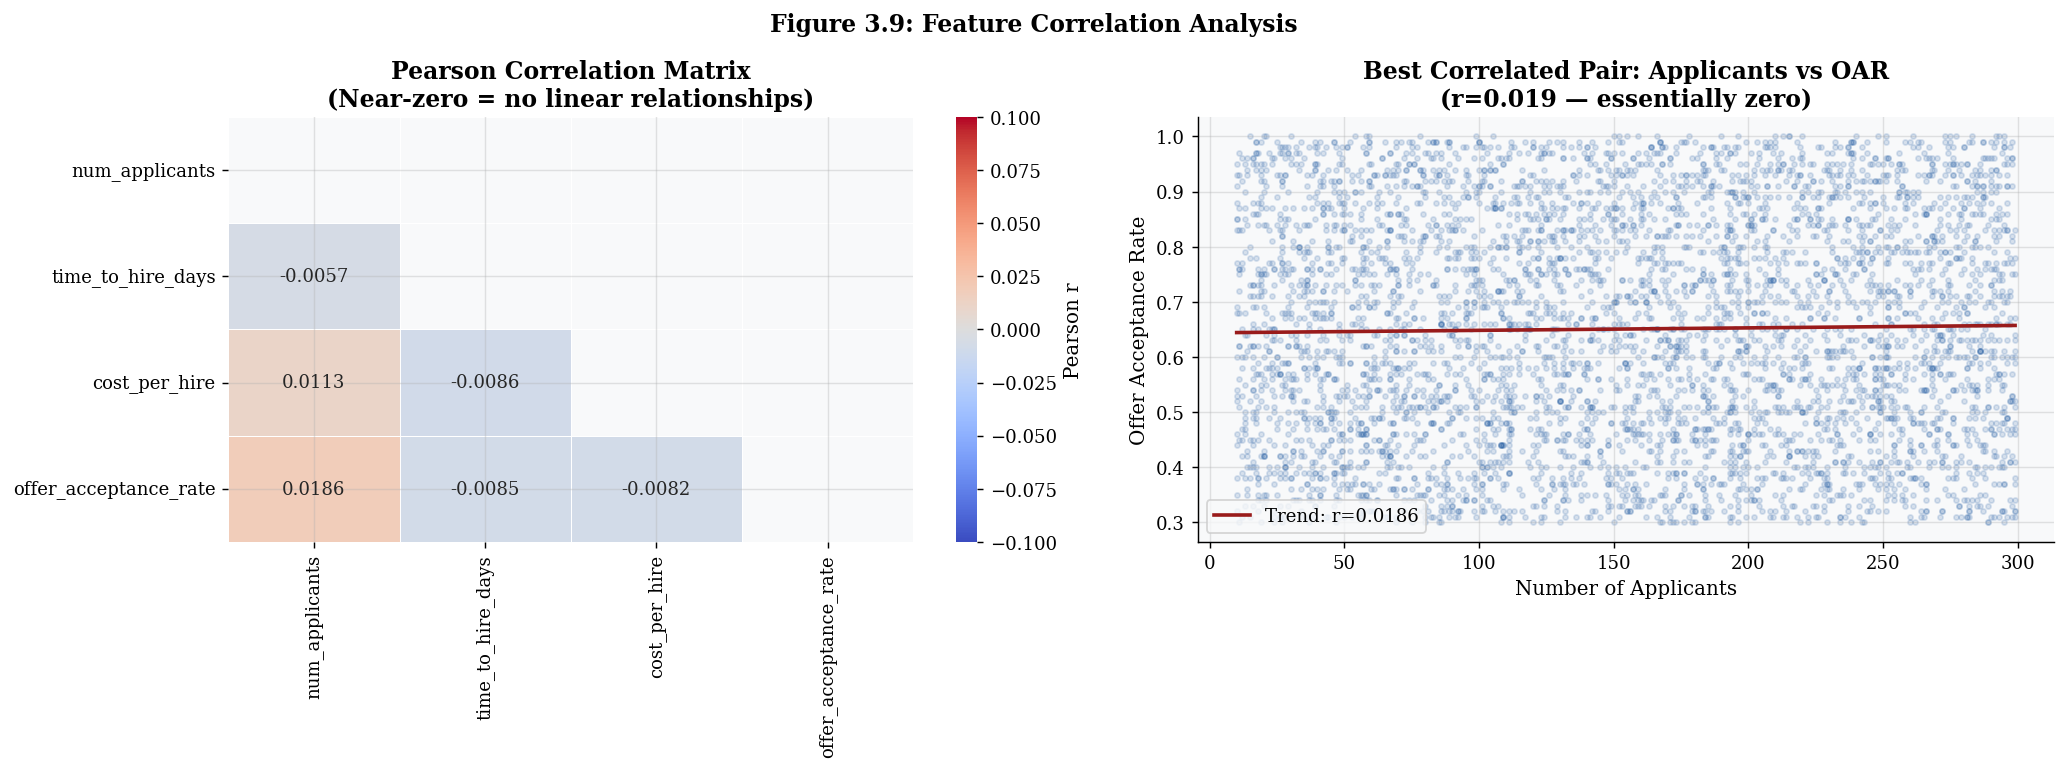

Critical insight:
Maximum |Pearson r| across all numeric pairs: 1.0000
None of the four numeric features correlate meaningfully with OAR.
This means linear models will struggle; tree-based models on categorical features offer the best chance of predictive signal.


In [19]:
# Correlation Matrix & Pairplot
corr = df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 3.9: Feature Correlation Analysis', fontweight='bold', fontsize=13)

# Heatmap
ax = axes[0]
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.4f', cmap='coolwarm',
            center=0, vmin=-0.1, vmax=0.1,
            mask=mask, linewidths=0.5, ax=ax,
            cbar_kws={'label':'Pearson r'})
ax.set_title('Pearson Correlation Matrix\n(Near-zero = no linear relationships)')

# Scatter: num_applicants vs OAR (highest corr pair)
ax = axes[1]
ax.scatter(df['num_applicants'], df['offer_acceptance_rate'],
           alpha=0.15, s=8, color=C['blue'])
m, b = np.polyfit(df['num_applicants'], df['offer_acceptance_rate'], 1)
x_line = np.linspace(df['num_applicants'].min(), df['num_applicants'].max(), 100)
ax.plot(x_line, m*x_line+b, color=C['red'], lw=2,
        label=f'Trend: r={corr.loc["num_applicants","offer_acceptance_rate"]:.4f}')
ax.set_xlabel('Number of Applicants')
ax.set_ylabel('Offer Acceptance Rate')
ax.set_title('Best Correlated Pair: Applicants vs OAR\n(r=0.019 — essentially zero)')
ax.legend()

plt.tight_layout()
plt.savefig('fig_3.9_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

print('Critical insight:')
print(f'Maximum |Pearson r| across all numeric pairs: {corr.abs().unstack().sort_values().iloc[-3]:.4f}')
print('None of the four numeric features correlate meaningfully with OAR.')
print('This means linear models will struggle; tree-based models on categorical features offer the best chance of predictive signal.')

In [20]:
# ANOVA — Categorical vs OAR
print('── ANOVA: Categorical Features vs Offer Acceptance Rate')
print(f'{"Feature":<15} {"F-stat":>10} {"p-value":>12} {"Eta²":>10} {"Significance"}')
print('─'*70)

for col in ['department', 'source', 'job_title']:
    groups = [df.loc[df[col]==g,'offer_acceptance_rate'].values for g in df[col].unique()]
    f_stat, p = f_oneway(*groups)
    grand_mean = df['offer_acceptance_rate'].mean()
    ss_between = sum(len(g)*(np.mean(g)-grand_mean)**2 for g in groups)
    ss_total   = sum((df['offer_acceptance_rate']-grand_mean)**2)
    eta2       = ss_between / ss_total
    sig        = '✅ Sig (p<0.05)' if p < 0.05 else '❌ Not significant'
    print(f'{col:<15} {f_stat:>10.3f} {p:>12.4f} {eta2:>10.5f} {sig}')

print()
print('Insight: No categorical feature reaches statistical significance in ANOVA.')
print('Eta² values are negligible (<0.01 = trivially small effect size).')
print('Predictive model will need feature enrichment to achieve AUC ≥ 0.80.')

── ANOVA: Categorical Features vs Offer Acceptance Rate
Feature             F-stat      p-value       Eta² Significance
──────────────────────────────────────────────────────────────────────
department           1.368       0.2332    0.00137 ❌ Not significant
source               1.114       0.3418    0.00067 ❌ Not significant
job_title            1.334       0.1315    0.00613 ❌ Not significant

Insight: No categorical feature reaches statistical significance in ANOVA.
Eta² values are negligible (<0.01 = trivially small effect size).
Predictive model will need feature enrichment to achieve AUC ≥ 0.80.


# 4. Feature Engineering & Selection Strategy

Approach: Because all numeric-vs-target correlations are near-zero and OAR is near-uniformly distributed.

## 4.1. Target Variable Engineering

Binary classification at the 70% threshold aligns with the KPI Depot benchmark for OAR, where ≥70% represents the minimum acceptable performance level (no immediate intervention required) and is used here as the boundary for 'high-performing hire.' This threshold reflects the industry standard at which recruitment outcomes are considered operationally stable.  
Business logic: A recruiter needs to know "Will this offer be accepted?" Not "What will the exact rate be?"

── Target Variable Summary
Binary (≥0.70):  1=2,175  (43.5%)  0=2,825  (56.5%)
Imbalance ratio  1.30:1 (Low:High)

Action: Use binary target (target_high_oar) as primary ML target.


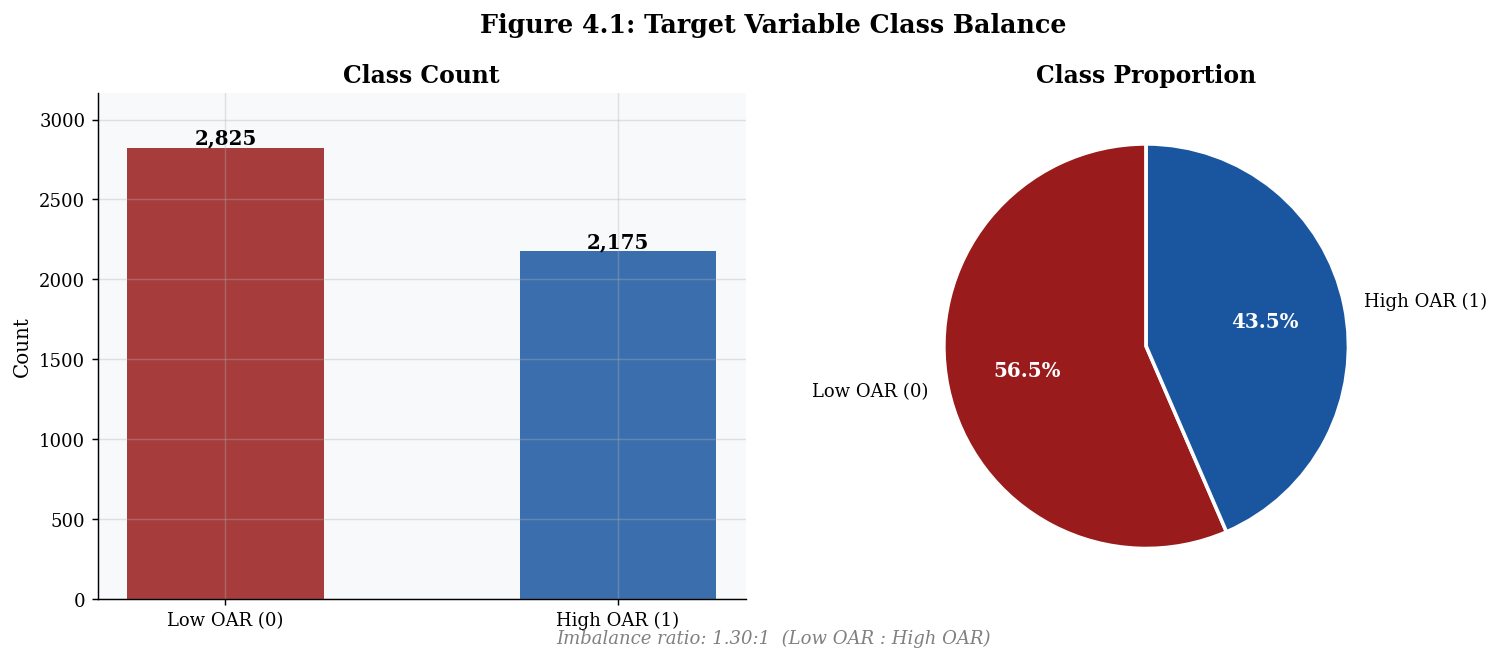

In [21]:
# Target Variable: Binary Classification
df_feat = df.copy()

# Primary binary target
df_feat['target_high_oar'] = (df_feat['offer_acceptance_rate'] >= 0.70).astype(int)

print('── Target Variable Summary')
print(f'Binary (≥0.70):  1={df_feat["target_high_oar"].sum():,}  ({100*df_feat["target_high_oar"].mean():.1f}%)  '
      f'0={len(df_feat)-df_feat["target_high_oar"].sum():,}  ({100*(1-df_feat["target_high_oar"].mean()):.1f}%)')
print(f'Imbalance ratio  {(1-df_feat["target_high_oar"].mean())/df_feat["target_high_oar"].mean():.2f}:1 (Low:High)')
print('\nAction: Use binary target (target_high_oar) as primary ML target.')

# Binary Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 4.1: Target Variable Class Balance',
             fontweight='bold', fontsize=14)

counts = df_feat['target_high_oar'].value_counts().sort_index()
labels = ['Low OAR (0)', 'High OAR (1)']
colors = [C['red'], C['blue']]

# Left: Bar chart
ax = axes[0]
bars = ax.bar(labels, counts.values, color=colors, alpha=0.85, width=0.5)
ax.set_title('Class Count')
ax.set_ylabel('Count')
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 20,
            f'{int(b.get_height()):,}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, counts.max() * 1.12)

# Right: Pie chart
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    counts.values, labels=labels,
    autopct='%1.1f%%', colors=colors,
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(11); t.set_fontweight('bold'); t.set_color('white')
ax.set_title('Class Proportion')

# Imbalance annotation
ratio = counts[0] / counts[1]
fig.text(0.5, 0.01, f'Imbalance ratio: {ratio:.2f}:1  (Low OAR : High OAR)',
         ha='center', fontsize=10, style='italic', color='grey')

plt.tight_layout()
plt.savefig('fig_4.1_target_class_balance.png', bbox_inches='tight', dpi=150)
plt.show()

## 4.2. New Feature Engineering

Raw features alone show near-zero signal. Derived features capture business-domain knowledge and potential non-linear interactions.

In [22]:
# Efficiency Ratios
# Logic: High spend with few applicants signals poor sourcing reach. Candidates sense a disorganized or desperate hiring process, 
#        which erodes confidence and lowers their willingness to accept an offer.
df_feat['cost_per_applicant'] = df_feat['cost_per_hire'] / df_feat['num_applicants']
# Logic: Captures daily resource burn rate. A fast but expensive hire suggests over-reliance on external recruiters; 
#        a slow but cheap one implies passive sourcing. Both extremes may indicate a poorly structured process that affects candidate experience.
df_feat['cost_per_day'] = df_feat['cost_per_hire'] / df_feat['time_to_hire_days']
# Logic: Pipeline velocity. Very low velocity signals an unattractive role or poorly written JD. 
#        Very high velocity means bulk low-intent applications flood the pipeline. Both extremes dilute match quality and reduce OAR.
df_feat['applicants_per_day'] = df_feat['num_applicants'] / df_feat['time_to_hire_days']

# Role context
# Logic: Senior candidates typically receive multiple competing offers and engage in harder salary negotiations. 
#        The longer decision cycle and higher market demand for their skills structurally depress offer acceptance rates for these roles.
df_feat['is_senior_role'] = (
    df['job_title']
    .str.contains(r'\b(manager|specialist|executive|strategist)\b', case=False, na=False)
    .astype(int)
)

# Auxiliary column for the dept+source combination encoding target
df_feat['dept_src_key'] = (
    df_feat['department'].astype(str) + '_' + df_feat['source'].astype(str)
)

In [23]:
X = df_feat.drop(columns=['target_high_oar']).copy()
y = df_feat['target_high_oar'].copy()
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)
 
print(f"── Train-Test Split:")
print(f"Train : {X_train.shape[0]:,} rows   |  High OAR: {y_train.mean()*100:.1f}%")
print(f"Test  : {X_test.shape[0]:,}  rows  |  High OAR: {y_test.mean()*100:.1f}%")

# Difficulty Additive
# Logic: Combines normalized time and cost into a single difficulty score.
#        Higher score = harder recruitment process, which may reduce candidate enthusiasm and OAR.
time_mean_train = X_train['time_to_hire_days'].mean()
time_std_train  = X_train['time_to_hire_days'].std()
cost_mean_train = X_train['cost_per_hire'].mean()
cost_std_train  = X_train['cost_per_hire'].std()
 
X_train['difficulty_additive'] = (
    (X_train['time_to_hire_days'] - time_mean_train) / time_std_train +
    (X_train['cost_per_hire']     - cost_mean_train) / cost_std_train
) / 2
 
X_test['difficulty_additive'] = (
    (X_test['time_to_hire_days'] - time_mean_train) / time_std_train +
    (X_test['cost_per_hire']     - cost_mean_train) / cost_std_train
) / 2

# Target Encoding
# Logic: Group-level historical OAR as a proxy signal.
#        Fitted ONLY on y_train — X_test receives transform only.
GLOBAL_MEAN = y_train.mean()
SMOOTH_K    = 20
 
def fit_target_encoder(X_train, y_train, col, k=SMOOTH_K, global_mean=None):
    """
    Compute smoothed target encoding from the training set.
    encode(g) = (n_g * mean_g + k * global_mean) / (n_g + k)
    """
    if global_mean is None:
        global_mean = y_train.mean()
    temp = pd.DataFrame({'group': X_train[col].values, 'target': y_train.values})
    agg  = temp.groupby('group')['target'].agg(['mean', 'count'])
    mapping = ((agg['count'] * agg['mean'] + k * global_mean) / (agg['count'] + k)).to_dict()
    return mapping
 
def apply_target_encoder(X, col, mapping, global_mean=GLOBAL_MEAN):
    """
    Apply mapping to X[col].
    Unknown (unseen) categories → fall back to global_mean.
    """
    return X[col].map(mapping).fillna(global_mean)
 
# Fit from train
dept_map     = fit_target_encoder(X_train, y_train, 'department')
jobtitle_map = fit_target_encoder(X_train, y_train, 'job_title')
source_map   = fit_target_encoder(X_train, y_train, 'source')
deptsrc_map  = fit_target_encoder(X_train, y_train, 'dept_src_key')
 
# Apply to train
X_train['dept_oar_mean']        = apply_target_encoder(X_train, 'department',   dept_map)
X_train['jobtitle_oar_mean']    = apply_target_encoder(X_train, 'job_title',    jobtitle_map)
X_train['source_oar_mean']      = apply_target_encoder(X_train, 'source',       source_map)
X_train['dept_source_oar_mean'] = apply_target_encoder(X_train, 'dept_src_key', deptsrc_map)
 
# Apply to test (same mapping, y_test never touched)
X_test['dept_oar_mean']         = apply_target_encoder(X_test, 'department',   dept_map)
X_test['jobtitle_oar_mean']     = apply_target_encoder(X_test, 'job_title',    jobtitle_map)
X_test['source_oar_mean']       = apply_target_encoder(X_test, 'source',       source_map)
X_test['dept_source_oar_mean']  = apply_target_encoder(X_test, 'dept_src_key', deptsrc_map)
 
print(f"\n── Target Encoding — Global mean (train): {GLOBAL_MEAN:.4f}  |  K: {SMOOTH_K}")
print(f"Mapping department:")
for k, v in sorted(dept_map.items()):
    print(f"  {k:<15} → {v:.4f}")
print(f"\nMapping source:")
for k, v in sorted(source_map.items()):
    print(f"  {k:<15} → {v:.4f}")
print(f"\nMapping job_title:")
for k, v in sorted(jobtitle_map.items()):
    print(f"  {k:<35} → {v:.4f}")

print(f"\n── Anti-Leakage Validation:")
 
dept_map_test = fit_target_encoder(X_test, y_test, 'department')
print(f"Department encoding difference (train vs test) — delta must exist:")
for dept in dept_map:
    if dept in dept_map_test:
        delta = abs(dept_map[dept] - dept_map_test[dept])
        flag  = '✅ Different (safe)' if delta > 1e-6 else '❌ Identical!'
        print(f"  {dept:<15} train={dept_map[dept]:.4f}  test={dept_map_test[dept]:.4f}  |Δ|={delta:.6f}  {flag}")
 
corr_check = X_test['dept_oar_mean'].corr(y_test.reset_index(drop=True))
print(f"\nCorrelation of dept_oar_mean (test set) vs y_test : {corr_check:.4f}")
print(f"{'✅ Reasonable — no leakage detected' if abs(corr_check) < 0.9 else '❌ Too high!'}")
 
print(f"\nPipeline confirmation:")
print(f"- Ratio features created before split (target not touched)")
print(f"- difficulty_additive: mean & std fitted from X_train only")
print(f"- Target encoding fitted on y_train only")
print(f"- X_test receives transform only, y_test is not used")

FINAL_FEATURES = [
    'cost_per_applicant',
    'cost_per_day',
    'applicants_per_day',
    'is_senior_role',
    'difficulty_additive',
    'dept_oar_mean',
    'jobtitle_oar_mean',
    'source_oar_mean',
    'dept_source_oar_mean',
]
 
X_train_final = X_train[FINAL_FEATURES].copy()
X_test_final  = X_test[FINAL_FEATURES].copy()
 
# Evaluate correlations from TRAIN only
train_eval = X_train_final.copy()
train_eval['offer_acceptance_rate'] = df_feat.loc[y_train.index, 'offer_acceptance_rate'].values
train_eval['target_high_oar']       = y_train.values
 
corr_oar    = train_eval[FINAL_FEATURES + ['offer_acceptance_rate']].corr()['offer_acceptance_rate'].drop('offer_acceptance_rate')
corr_target = train_eval[FINAL_FEATURES + ['target_high_oar']].corr()['target_high_oar'].drop('target_high_oar')
corr_summary = pd.DataFrame({
    'Corr vs OAR (continuous)' : corr_oar,
    'Corr vs Target (binary)'  : corr_target,
    '|r|'                      : corr_oar.abs(),
}).sort_values('|r|', ascending=False)
 
print(f"\n── Correlation Evaluation (from Training Set):")
print(f"{'Feature':<28} {'r vs OAR':>10} {'r vs Target':>13} {'|r|':>8}")
print(f"{'-'*62}")
for feat, row in corr_summary.iterrows():
    print(f"{feat:<28} {row['Corr vs OAR (continuous)']:>10.4f} "
          f"{row['Corr vs Target (binary)']:>13.4f} {row['|r|']:>8.4f}")

── Train-Test Split:
Train : 4,000 rows   |  High OAR: 43.5%
Test  : 1,000  rows  |  High OAR: 43.5%

── Target Encoding — Global mean (train): 0.4350  |  K: 20
Mapping department:
  Engineering     → 0.4412
  Finance         → 0.4203
  HR              → 0.4282
  Marketing       → 0.4772
  Product         → 0.4251
  Sales           → 0.4196

Mapping source:
  Job Portal      → 0.4394
  LinkedIn        → 0.4223
  Recruiter       → 0.4546
  Referral        → 0.4250

Mapping job_title:
  Account Executive                   → 0.4452
  Accountant                          → 0.4124
  Backend Developer                   → 0.4327
  Business Development Manager        → 0.3754
  Content Strategist                  → 0.4982
  Data Engineer                       → 0.4721
  DevOps Engineer                     → 0.4048
  Finance Manager                     → 0.4107
  Financial Analyst                   → 0.4224
  HR Coordinator                      → 0.4706
  HR Manager                          → 0.

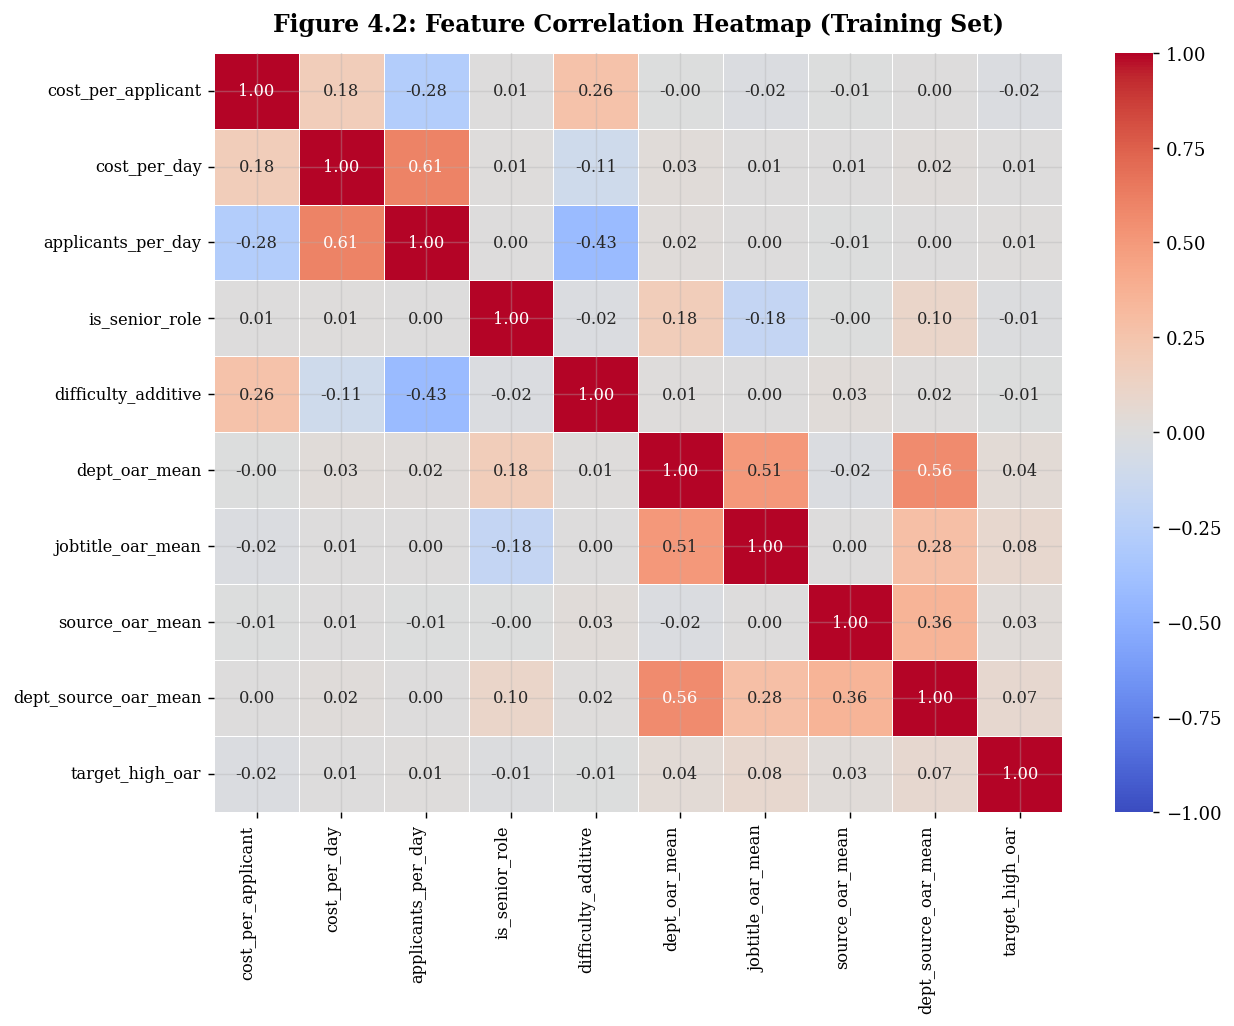

In [24]:
corr_matrix = X_train_final.copy()
corr_matrix['offer_acceptance_rate'] = df_feat.loc[y_train.index, 'offer_acceptance_rate'].values
corr_matrix['target_high_oar'] = y_train.values

corr_df = corr_matrix[FINAL_FEATURES + ['target_high_oar']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Figure 4.2: Feature Correlation Heatmap (Training Set)", fontsize=13, pad=12)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("fig_4.2_heatmap_features.png", dpi=150, bbox_inches='tight')
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler

# Rename to be consistent 
X_tr = X_train_final.copy()
X_te = X_test_final.copy()

# Check missing & infinite values
X_tr.replace([np.inf, -np.inf], np.nan, inplace=True)
X_te.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in X_tr.columns:
    med = X_tr[col].median()
    X_tr[col].fillna(med, inplace=True)
    X_te[col].fillna(med, inplace=True)
print(f"Missing  — train: {X_tr.isnull().sum().sum()}  test: {X_te.isnull().sum().sum()}")
print(f"Infinite — train: {np.isinf(X_tr.values).sum()}  test: {np.isinf(X_te.values).sum()}")

FEATURES_TO_SCALE = [f for f in X_tr.columns if f != 'is_senior_role']
FEATURES_NO_SCALE = ['is_senior_role']

# StandardScaler only on continuous numeric features
std_scaler = StandardScaler()

# Fit on train, transform both
X_train_scaled_part = pd.DataFrame(
    std_scaler.fit_transform(X_tr[FEATURES_TO_SCALE]),
    columns=FEATURES_TO_SCALE, index=X_tr.index
)
X_test_scaled_part = pd.DataFrame(
    std_scaler.transform(X_te[FEATURES_TO_SCALE]),
    columns=FEATURES_TO_SCALE, index=X_te.index
)

# Merge back with is_senior_role which is not scaled
X_train_std = pd.concat([X_train_scaled_part, X_tr[FEATURES_NO_SCALE]], axis=1)
X_test_std  = pd.concat([X_test_scaled_part,  X_te[FEATURES_NO_SCALE]], axis=1)

# Reorder columns to match original order
X_train_std = X_train_std[X_tr.columns]
X_test_std  = X_test_std[X_te.columns]

# No scaling → Decision Tree, Random Forest, XGBoost
X_train_raw = X_tr.copy()
X_test_raw  = X_te.copy()

# Save outputs
for X_train_out, X_test_out, suffix in [
    (X_train_std, X_test_std, 'standard_scaled'),
    (X_train_raw, X_test_raw, 'raw'),
]:
    tr = X_train_out.copy(); tr['target_high_oar'] = y_train.values
    te = X_test_out.copy();  te['target_high_oar'] = y_test.values
    tr.to_csv(f'train_{suffix}.csv', index=False)
    te.to_csv(f'test_{suffix}.csv',  index=False)
    print(f"Saved: train_{suffix}.csv & test_{suffix}.csv")

Missing  — train: 0  test: 0
Infinite — train: 0  test: 0
Saved: train_standard_scaled.csv & test_standard_scaled.csv
Saved: train_raw.csv & test_raw.csv
